# define

## TODO:
- salikt flagus, lai redzami vārdi kuriem vēl netika atrasts atbilstošs (vēlāk noderēs salīdzinot atvasinājumus)
- parādīt purpura krāsā ja pārbīdīts vārds, un par cik
- sāk meklēšanu kā tagad tieši no 0 ofseta, tad nākamo skatās +- pēdējais lietotias ofsets. ja nav, tad bīdās no o pa biškum un no ofseta pa biškum.


In [4]:
from pathlib import Path
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup
import difflib
import os
from typing import List, Dict, Tuple
import json
from datetime import datetime
import re
from lxml import etree
import json

import pandas as pd

nt_stubchapters = ["matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]

def element_to_dict(element):
    """Convert an lxml Element to a dictionary that can be JSON serialized"""
    result = {}
    
    if element.attrib:
        result['@attributes'] = dict(element.attrib)
    
    if element.text and element.text.strip():
        result['#text'] = element.text.strip()
    
    children = {}
    for child in element:
        if len(child) == 0:
            if child.text and child.text.strip():
                children[child.tag] = child.text.strip()
        else:
            children[child.tag] = element_to_dict(child)
    
    if children:
        result.update(children)
    
    return result

def extract_text_and_number(text):
    """
    Extract text and number from a string containing letters/spaces followed by a number.
    
    Args:
        text (str): Input string containing text and a number
        
    Returns:
        tuple: (text_part, number) or None if no valid pattern found
    """
    pattern = r'^([a-zA-Z\s\d]+)\s+(\d+)$'
    match = re.match(pattern, text.strip())
    return (match.group(1).strip().lower(), int(match.group(2))) if match else None

#def proiel_to_biblehub_chaps(text):
#    current_book, chapter = extract_text_and_number(text)
#    #return f"{chapter}_{current_book.lower()}" if current_book is not None else None

def tt(ch: str):
    return tr_ch_el_bh(ch)
def tr_ch_el_bh(ch: str):
    return ch.replace(" ", "_").lower()

class BibleSourceParser:
    def __init__(self):
        self.xml_parser = etree.XMLParser(resolve_entities=False, no_network=True)
        
    def parse_xml_source_proiel(self, xml_path: str, save_result= False) -> Dict[str, List[Dict]]:
        """Parse XML source from PROIEL project"""
        parser = self.xml_parser
        tree = etree.parse(xml_path, parser=parser)
        root = tree.getroot()
        
        result = {}
        bad_result = {}
        empty_result = {}
        df_result = []
        current_book = None
        
        # Use lxml's faster XPath expressions
        divs = root.xpath(".//div")
        ####attrdict = {}
        
        chdone = 0
        totchs = len(divs)
        for d in divs:
            current_book, chapter = extract_text_and_number(d.find("title").text.lower())
            current_book = tt(current_book)
            result[f"{current_book}_{chapter}"] = []
            print(f"{current_book} {chapter} ( {float(chdone)/float(totchs)*100:.1f}% )")
            #print(current_book == "hebrews")
            
            verse_idx = 1
            sentences = d.xpath('sentence')
            for stn in range(len(sentences)):
                sentence = sentences[stn]
                #sentence_tokens = []
                word_idx = 0
                
                tokens = sentence.xpath('token')
                for ct in range(len(tokens)):
                    token = tokens[ct]
                    cittpartemtytokenswtf = token.attrib.get('citation-part', '')
                    
                    if not cittpartemtytokenswtf:
                        if f"{current_book}_{chapter}" not in bad_result:
                            bad_result[f"{current_book}_{chapter}"] = []
                        bad_result[f"{current_book}_{chapter}"].append(element_to_dict(token))
                        continue
                    emptytokenmarker = token.attrib.get('empty-token-sort', '')
                    if emptytokenmarker:
                        if f"{current_book}_{chapter}" not in empty_result:
                            empty_result[f"{current_book}_{chapter}"] = []
                        empty_result[f"{current_book}_{chapter}"].append(element_to_dict(token))
                        continue
                    #####for attr in token.attrib:
                        ####attrdict[attr] = f"token.attrib.get('{attr}', ''),"
                    versenum = int(token.attrib['citation-part'].split(".")[-1])
                    if(len(result[f"{current_book}_{chapter}"])<versenum):
                        for jj in range(len(result[f"{current_book}_{chapter}"]),versenum):
                            result[f"{current_book}_{chapter}"].append([])
                            #                    if(current_book == "Hebrews"):
                            #                        print(f"{versenum} -> {verse_idx}")
                            #if(versenum != verse_idx):
                            #    result[f"{current_book}_{chapter}"].append(sentence_tokens)
                            #    sentence_tokens =[]
                            #    verse_idx+=1
                    xdata = {
                        ######## text is inside form attribute(!)                        'text': token.text.strip(),
                        'verse': versenum,
                        'word': word_idx,
                        'id' : token.attrib.get('id', ''),
                        'form' : token.attrib.get('form', ''),
                        'citation-part' : token.attrib.get('citation-part', ''),
                        'lemma' : token.attrib.get('lemma', ''),
                        'part-of-speech' : token.attrib.get('part-of-speech', ''),
                        'morphology' : token.attrib.get('morphology', ''),
                        'head-id' : token.attrib.get('head-id', ''),
                        'relation' : token.attrib.get('relation', ''),
                        'presentation-after' : token.attrib.get('presentation-after', ''),
                        'information-status' : token.attrib.get('information-status', ''),
                        'empty-token-sort' : token.attrib.get('empty-token-sort', ''),
                        'antecedent-id' : token.attrib.get('antecedent-id', ''),
                        'presentation-before' : token.attrib.get('presentation-before', ''),
                        'contrast-group' : token.attrib.get('contrast-group', ''),
                        'sentence': stn,
                        ####"attrs": dict(token.attrib)
                    }
                    #sentence_tokens.append(xdata)
                    result[f"{current_book}_{chapter}"][versenum-1].append(xdata)
                    xdata['book'] = current_book
                    xdata['chapter'] = chapter
                    df_result.append(xdata)
                    word_idx += 1
                
            chdone += 1
            #result[f"{current_book}_{chapter}"].append(sentence_tokens)
        ####print(attrdict)
        if(save_result):
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            filename = f"{timestamp}_badparses.txt"
            with open(filename, "w") as file:
                json.dump(bad_result, file, indent=2)
            filename = f"{timestamp}_emptytokens.txt"
            with open(filename, "w") as file:
                json.dump(empty_result, file, indent=2)
            dbname = f"{timestamp}_el_proiel_el.csv"
                # Create DataFrame and write to CSV
            df = pd.DataFrame(df_result)
            
            # Ensure output directory exists
            Path(dbname).parent.mkdir(parents=True, exist_ok=True)
            
            # Write to CSV with proper formatting
            df.to_csv(
                dbname,
                index=False,
                encoding='utf-8',
                quoting=1, 
                escapechar='\\'
            )
        return result

def str_getfrom_token_first(s1: str, tok: str):
    if not tok: return str
    pos = s1.find(tok)
    return s1[pos:] if pos >= 0 else s1

class BibleHTMLParser:
    def __init__(self):
        pass
    
    def parse_html_folder_biblehub(self, folder_path: str, book_filter: List[str]= None, save_result=False) -> Dict[str, List[List[str]]]:
        """Parse HTML files from BibleHub"""
        result = {}
        sentence_tokens = []
        df_result = []
        iterator_folders = []
        if book_filter is None:
            iterator_folders = os.listdir(folder_path)
        else:
            #if any(book.lower() in folder.lower() for book in book_filter)
            #dircont =
            iterator_folders = [n.lower() for n in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, n))
                       and n.lower() in book_filter]
            #for book in book_filter:
            #    if book.lower()  in dircont: iterator_folders.append(book)
        urls_greek = {}
        chdone = 0
        totchs = len(iterator_folders)
        for fold in iterator_folders:
            chapsnames = [filename for filename in os.listdir(folder_path.strip(os.path.sep)+os.path.sep+fold) 
                          if filename.endswith('.htm') or filename.endswith('.html')]
            ccchdone = 0
            totchhh = len(chapsnames)
            for filename in chapsnames:
                if(True):
                    chapter = os.path.splitext(filename)[0]
                    current_book = fold
                    result[f"{current_book}_{chapter}"] = []
                    print(f"{current_book} {chapter} ( {float(chdone)/float(totchs)*float(100)+(float(1)/float(totchs))*(float(ccchdone)/float(totchhh))*float(100):.1f}% )")
                    soup = BeautifulSoup(open(os.path.join(folder_path, fold, filename)), 'html.parser')
                    
                    table_spans = soup.find_all('table', class_='tablefloat')
                    curr_verse = 1
                    strong_num=-1
                    strong_title = ''
                    strong_en_title = ''
                    translit=''
                    translit_title=''
                    form = ''
                    form_en = ''
                    curr_node = None
                    word_idx = 0
                    for tbc in range(len(table_spans)):
                        table = table_spans[tbc]
                        #verse number?
                        curr_node = table.find("span", class_='reftop3')
                        if curr_node is not None:
                            # nbsp;
                            curr_verse = int(curr_node.text.strip("\xa0"))
                            word_idx = 0
                        
                        if(len(result[f"{current_book}_{chapter}"])<curr_verse):
                            for jj in range(len(result[f"{current_book}_{chapter}"]),curr_verse):
                                result[f"{current_book}_{chapter}"].append([])

                        #strongs title?
                        curr_node = table.find("span", class_='pos')
                        if curr_node is not None:
                            curr_node = curr_node.find('a')
                            if curr_node is not None:
                                strong_num = int(curr_node.text)
                                strong_title = curr_node.text + str_getfrom_token_first(curr_node.attrs.get('title', ''), ':')
                                attrb = curr_node.attrs.get('href', '')
                                if(attrb != ''):
                                    if(attrb.startswith('/greek')):
                                        urls_greek[attrb]=f"curl -O https://www.biblehub.com{attrb}"
                                        
                        #englishmans concordance
                        curr_node = table.find("span", class_='strongsnt2')
                        if curr_node is not None:
                            curr_node = curr_node.find('a')
                            if curr_node is not None:
                                strong_en_title = curr_node.text
                                attrb = curr_node.attrs.get('href', '')
                                if(attrb != ''):
                                    if(attrb.startswith('/greek')):
                                        urls_greek[attrb]=f"curl -O https://www.biblehub.com{attrb}"
                            
                        #translit
                        curr_node = table.find("span", class_='translit')
                        if curr_node is not None:
                            curr_node = curr_node.find('a')
                            if curr_node is not None:
                                attrb = curr_node.attrs.get('href', '')
                                if(attrb != ''):
                                    if(attrb.startswith('/greek')):
                                        urls_greek[attrb]=f"curl -O https://www.biblehub.com{attrb}"
                                translit_title = curr_node.attrs.get('title', '').replace("\xa0", ' ')
                                translit = curr_node.text.replace("\xa0", ' ')
                        
                        #greek text
                        curr_node = table.find("span", class_='greek')
                        if curr_node is not None:
                            form = curr_node.text.replace("\xa0", ' ')
                        
                        #en text
                        curr_node = table.find("span", class_='eng')
                        if curr_node is not None:
                            form_en = curr_node.text.replace("\xa0", ' ')
                                    
                        xdata = {
                        ######## text is inside form attribute(!)                        'text': token.text.strip(),
                        'verse': curr_verse,
                        'word': word_idx,
                        #'id' : token.attrib.get('id', ''),
                        'form' : form,
                        'form_en': form_en,
                        #'citation-part' : token.attrib.get('citation-part', ''),
                        #'lemma' : token.attrib.get('lemma', ''),
                        #'part-of-speech' : token.attrib.get('part-of-speech', ''),
                        #'morphology' : token.attrib.get('morphology', ''),
                        #'head-id' : token.attrib.get('head-id', ''),
                        #'relation' : token.attrib.get('relation', ''),
                        #'presentation-after' : token.attrib.get('presentation-after', ''),
                        #'information-status' : token.attrib.get('information-status', ''),
                        #'empty-token-sort' : token.attrib.get('empty-token-sort', ''),
                        #'antecedent-id' : token.attrib.get('antecedent-id', ''),
                        #'presentation-before' : token.attrib.get('presentation-before', ''),
                        #'contrast-group' : token.attrib.get('contrast-group', ''),
                        ####"attrs": dict(token.attrib)
                        'strong_num': strong_num,
                        'strong_title' : strong_title,
                        'strong_en_title' : strong_en_title,
                        'translit': translit,
                        'translit_title': translit_title
                    }
                        result[f"{current_book}_{chapter}"][curr_verse-1].append(xdata)
                        xdata['book'] = current_book
                        xdata['chapter'] = chapter
                        df_result.append(xdata)
                        word_idx += 1
                ccchdone +=1
            chdone += 1

        if(save_result):
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            filename = f"{timestamp}_dload.sh"
            with open(filename, "w") as file:
                for k, v in urls_greek.items():
                    file.write(f"{v}\n")
            dbname = f"{timestamp}_biblehub_el_en_direct.csv"
                # Create DataFrame and write to CSV
            df = pd.DataFrame(df_result)
            
            # Ensure output directory exists
            Path(dbname).parent.mkdir(parents=True, exist_ok=True)
            
            # Write to CSV with proper formatting
            df.to_csv(
                dbname,
                index=False,
                encoding='utf-8',
                quoting=1, 
                escapechar='\\'
            )                    
        return result

class BibleComparator:
    def __init__(self):
        self.parser_xml = BibleSourceParser()
        self.parser_html = BibleHTMLParser()
        
    def compare_verses(self, xml_source: Dict[str, List[List[Dict]]], 
                      html_source: Dict[str, List[List[str]]]) -> List[Tuple]:
        """Compare verses and generate comparison tuples"""
        comparisons = []
        
        for book_chapter in xml_source.keys():
            if book_chapter in html_source:
                xml_verses = xml_source[book_chapter]
                html_verses = html_source[book_chapter]
                
                max_verses = max(len(xml_verses), len(html_verses))
                
                for verse_num in range(max_verses):
                    xml_verse = xml_verses[verse_num] if verse_num < len(xml_verses) else None
                    html_verse = html_verses[verse_num] if verse_num < len(html_verses) else None
                    
                    comparisons.append((book_chapter, verse_num + 1, xml_verse, html_verse))
        
        return comparisons
    
    def generate_html_report(self, comparisons: List[Tuple], 
                           output_path: str = 'comparison_report.html'):
        """Generate HTML report with interlinear comparison"""
        html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Bible Greek Sources Comparison</title>
    <style>
        .container { margin: 20px; font-family: Arial, sans-serif; }
        .verse-comparison { border-collapse: collapse; width: 100%; margin-bottom: 20px; }
        .verse-comparison td { padding: 8px; border: 1px solid #ddd; }
        .source-header { background-color: #f5f5f5; }
        .difference { background-color: #ffebee; }
        .addition { background-color: #e8f5e9; }
        .deletion { background-color: #ffebee; }
        .nav-buttons { margin-top: 10px; }
        .nav-button { padding: 5px 10px; margin-right: 5px; }
    </style>
</head>
<body>
    <div class="container">
        {}
    </div>
</body>
</html>
"""
        
        report_content = []
        
        for book_chapter, verse_num, xml_verse, html_verse in comparisons:
            report_content.append(f'<h2>{book_chapter}, Verse {verse_num}</h2>')
            
            if xml_verse and html_verse:
                # Compare verses
                diff = difflib.SequenceMatcher(None, 
                                             ' '.join(t['form'] for t in xml_verse),
                                             ' '.join(html_verse))
                
                # Generate comparison table
                table_rows = ['<table class="verse-comparison">']
                table_rows.append('<tr><th>PROIEL Source</th><th>BibleHub Source</th></tr>')
                
                # Get aligned sequences
                opcodes = diff.get_opcodes()
                for opcode in opcodes:
                    if opcode[0] == 'equal':
                        xml_words = ' '.join(t['form'] for t in xml_verse[opcode[1]:opcode[2]])
                        html_words = ' '.join(html_verse[opcode[3]:opcode[4]])
                        table_rows.append(f'<tr><td>{xml_words}</td><td>{html_words}</td></tr>')
                    elif opcode[0] == 'replace':
                        xml_words = ' '.join(t['form'] for t in xml_verse[opcode[1]:opcode[2]])
                        html_words = ' '.join(html_verse[opcode[3]:opcode[4]])
                        table_rows.append(f'<tr><td class="difference">{xml_words}</td><td class="difference">{html_words}</td></tr>')
                    elif opcode[0] == 'delete':
                        xml_words = ' '.join(t['form'] for t in xml_verse[opcode[1]:opcode[2]])
                        table_rows.append(f'<tr><td class="deletion">{xml_words}</td><td></td></tr>')
                    elif opcode[0] == 'insert':
                        html_words = ' '.join(html_verse[opcode[3]:opcode[4]])
                        table_rows.append(f'<tr><td></td><td class="addition">{html_words}</td></tr>')
                
                table_rows.append('</table>')
                report_content.append('\n'.join(table_rows))
            
            # Add navigation buttons
            report_content.append("""
                <div class="nav-buttons">
                    <button onclick="window.location.href='#'" class="nav-button">Top</button>
                    <button onclick="history.back()" class="nav-button">Previous</button>
                    <button onclick="history.forward()" class="nav-button">Next</button>
                </div>
            """)
        
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(html_template.format('\n'.join(report_content)))


In [1]:
#!mamba install -y lxml
#!mamba install -y pandas

# start work

In [2]:
#!curl -O https://t.noit.lol/g/25-03-25-bibsrces.zip
#!unzip 25-03-25-bibsrces.zip

In [5]:
comparator = BibleComparator()
#html_sources = comparator.parser_html.parse_html_folder_biblehub('../../00rebordn2/', nt_stubchapters, True)
#html_sources = comparator.parser_html.parse_html_folder_biblehub('../../00rebordn2/', ["hebrews"], False)
html_sources = comparator.parser_html.parse_html_folder_biblehub('b/', nt_stubchapters, True)

1_corinthians 1 ( 0.0% )


1_corinthians 10 ( 0.2% )
1_corinthians 11 ( 0.5% )
1_corinthians 12 ( 0.7% )
1_corinthians 13 ( 0.9% )
1_corinthians 14 ( 1.2% )
1_corinthians 15 ( 1.4% )
1_corinthians 16 ( 1.6% )
1_corinthians 2 ( 1.9% )
1_corinthians 3 ( 2.1% )
1_corinthians 4 ( 2.3% )
1_corinthians 5 ( 2.5% )
1_corinthians 6 ( 2.8% )
1_corinthians 7 ( 3.0% )
1_corinthians 8 ( 3.2% )
1_corinthians 9 ( 3.5% )
1_john 1 ( 3.7% )
1_john 2 ( 4.4% )
1_john 3 ( 5.2% )
1_john 4 ( 5.9% )
1_john 5 ( 6.7% )
1_peter 1 ( 7.4% )
1_peter 2 ( 8.1% )
1_peter 3 ( 8.9% )
1_peter 4 ( 9.6% )
1_peter 5 ( 10.4% )
1_thessalonians 1 ( 11.1% )
1_thessalonians 2 ( 11.9% )
1_thessalonians 3 ( 12.6% )
1_thessalonians 4 ( 13.3% )
1_thessalonians 5 ( 14.1% )
1_timothy 1 ( 14.8% )
1_timothy 2 ( 15.4% )
1_timothy 3 ( 16.0% )
1_timothy 4 ( 16.7% )
1_timothy 5 ( 17.3% )
1_timothy 6 ( 17.9% )
2_corinthians 1 ( 18.5% )
2_corinthians 10 ( 18.8% )
2_corinthians 11 ( 19.1% )
2_corinthians 12 ( 19.4% )
2_corinthians 13 ( 19.7% )
2_corinthians 2 ( 19.9% )


In [ ]:
#print(html_sources.keys())
#print(([j['verse'] for i in html_sources['mark_12'] for j in i if j.get('verse') == '1']))
#talist = [
#    itm 
#          for j in html_sources['mark_12'] 
#          for itm in j 
#          if int(itm['verse']) < 2
#          ]

#print(len(talist))
#print(talist[12])
print(html_sources['mark_12'][0][12])
print(int(html_sources['mark_12'][0][12]['verse']) <2)
#for i in range(1):
#    for j in range(30):
##        print(html_sources['mark_12'][i][j].get('verse')=='1')
#        print(len(html_sources['mark_12'][i][j]))

{'verse': 1, 'word': 12, 'form': 'καὶ', 'form_en': 'and', 'strong_num': 2532, 'strong_title': '2532: And, even, also, namely. ', 'strong_en_title': '[e]', 'translit': 'kai', 'translit_title': 'kai: And, even, also, namely. ', 'book': 'mark', 'chapter': '12'}
True


In [5]:
#proiel_to_biblehub_chaps(nt_stubchapters))
##xml_sources = comparator.parser_xml.parse_xml_source_proiel('./greek-nt.xml', True)#True)
xml_sources = comparator.parser_xml.parse_xml_source_proiel('./xm/greek-nt.xml', True)#True)
#xml_sources = comparator.parser_xml.parse_xml_source_proiel('./greek-nt-syn.xml', True)#True)


matthew 1 ( 0.0% )
matthew 2 ( 0.4% )
matthew 3 ( 0.8% )
matthew 4 ( 1.2% )
matthew 5 ( 1.6% )
matthew 6 ( 2.0% )
matthew 7 ( 2.4% )
matthew 8 ( 2.8% )
matthew 9 ( 3.2% )
matthew 10 ( 3.6% )
matthew 11 ( 4.0% )
matthew 12 ( 4.4% )
matthew 13 ( 4.8% )
matthew 14 ( 5.2% )
matthew 15 ( 5.6% )
matthew 16 ( 6.0% )
matthew 17 ( 6.5% )
matthew 18 ( 6.9% )
matthew 19 ( 7.3% )
matthew 20 ( 7.7% )
matthew 21 ( 8.1% )
matthew 22 ( 8.5% )
matthew 23 ( 8.9% )
matthew 24 ( 9.3% )
matthew 25 ( 9.7% )
matthew 26 ( 10.1% )
matthew 27 ( 10.5% )
matthew 28 ( 10.9% )
mark 1 ( 11.3% )
mark 2 ( 11.7% )
mark 3 ( 12.1% )
mark 4 ( 12.5% )
mark 5 ( 12.9% )
mark 6 ( 13.3% )
mark 7 ( 13.7% )
mark 8 ( 14.1% )
mark 9 ( 14.5% )
mark 10 ( 14.9% )
mark 11 ( 15.3% )
mark 12 ( 15.7% )
mark 13 ( 16.1% )
mark 14 ( 16.5% )
mark 15 ( 16.9% )
mark 16 ( 17.3% )
luke 1 ( 17.7% )
luke 2 ( 18.1% )
luke 3 ( 18.5% )
luke 4 ( 19.0% )
luke 5 ( 19.4% )
luke 6 ( 19.8% )
luke 7 ( 20.2% )
luke 8 ( 20.6% )
luke 9 ( 21.0% )
luke 10 ( 21.4

revelation 16 ( 97.2% )
revelation 17 ( 97.6% )
revelation 18 ( 98.0% )
revelation 19 ( 98.4% )
revelation 20 ( 98.8% )
revelation 21 ( 99.2% )
revelation 22 ( 99.6% )


# check data compatibility

In [6]:
def tt(ch: str):
    return tr_ch_el_bh(ch)
def tr_ch_el_bh(ch: str):
    return ch.replace(" ", "_").lower()

def ta(ch: str):
    return tr_ch_bh_el(ch)
def tr_ch_bh_el(ch: str):
    #return ch.replace("_", " ").lower()
    return ch[0].upper()+ ch[1:]

def ta(c: str):
    return c

print(xml_sources.keys())
print(html_sources.keys())
print(ta('mark_12'))
print(xml_sources[ta('mark_12')][2][0])
print(html_sources[('mark_12')][0][2])
#print(
#[item for list in xml_sources[ta('mark_12')] for item in  list
#          if item.get('verse') == '2' and item.get('word') == '0']

#)

dict_keys(['matthew_1', 'matthew_2', 'matthew_3', 'matthew_4', 'matthew_5', 'matthew_6', 'matthew_7', 'matthew_8', 'matthew_9', 'matthew_10', 'matthew_11', 'matthew_12', 'matthew_13', 'matthew_14', 'matthew_15', 'matthew_16', 'matthew_17', 'matthew_18', 'matthew_19', 'matthew_20', 'matthew_21', 'matthew_22', 'matthew_23', 'matthew_24', 'matthew_25', 'matthew_26', 'matthew_27', 'matthew_28', 'mark_1', 'mark_2', 'mark_3', 'mark_4', 'mark_5', 'mark_6', 'mark_7', 'mark_8', 'mark_9', 'mark_10', 'mark_11', 'mark_12', 'mark_13', 'mark_14', 'mark_15', 'mark_16', 'luke_1', 'luke_2', 'luke_3', 'luke_4', 'luke_5', 'luke_6', 'luke_7', 'luke_8', 'luke_9', 'luke_10', 'luke_11', 'luke_12', 'luke_13', 'luke_14', 'luke_15', 'luke_16', 'luke_17', 'luke_18', 'luke_19', 'luke_20', 'luke_21', 'luke_22', 'luke_23', 'luke_24', 'john_1', 'john_2', 'john_3', 'john_4', 'john_5', 'john_6', 'john_7', 'john_8', 'john_9', 'john_10', 'john_11', 'john_12', 'john_13', 'john_14', 'john_15', 'john_16', 'john_17', 'john_

In [ ]:
print(xml_sources[ta('hebrews_9')][26][1])
print(html_sources[('hebrews_9')][26][1])

{'verse': 27, 'word': 1, 'id': '469859', 'form': 'καθ’', 'citation-part': 'HEB 9.27', 'lemma': 'κατά', 'part-of-speech': 'R-', 'morphology': '---------n', 'head-id': '469861', 'relation': 'adv', 'presentation-after': ' ', 'information-status': '', 'empty-token-sort': '', 'antecedent-id': '', 'presentation-before': '', 'contrast-group': '', 'sentence': 20, 'book': 'hebrews', 'chapter': 9}
{'verse': 27, 'word': 1, 'form': 'καθ’', 'form_en': 'in', 'strong_num': 2596, 'strong_title': '2596: A primary particle; down, in varied relations (genitive, dative or accusative) with which it is joined).', 'strong_en_title': '[e]', 'translit': 'kath’', 'translit_title': 'kath’: A primary particle; down, in varied relations (genitive, dative or accusative) with which it is joined).', 'book': 'hebrews', 'chapter': '9'}


In [ ]:
len(html_sources[('hebrews_9')][0])

12

In [ ]:
print(len(xml_sources[('hebrews_9')]))
print(len(xml_sources[('hebrews_9')][20]))
print((xml_sources[('hebrews_9')][20][0]))

28
14
{'verse': 21, 'word': 0, 'id': '469734', 'form': 'καὶ', 'citation-part': 'HEB 9.21', 'lemma': 'καί', 'part-of-speech': 'C-', 'morphology': '---------n', 'head-id': '469747', 'relation': 'obj', 'presentation-after': ' ', 'information-status': '', 'empty-token-sort': '', 'antecedent-id': '', 'presentation-before': '', 'contrast-group': '', 'sentence': 14, 'book': 'hebrews', 'chapter': 9}


In [ ]:
for i in range(28):
    print((xml_sources[ta('hebrews_9')][i][0]))

{'verse': 1, 'word': 0, 'id': '469330', 'form': 'Εἶχε', 'citation-part': 'HEB 9.1', 'lemma': 'ἔχω', 'part-of-speech': 'V-', 'morphology': '3siia----i', 'head-id': '', 'relation': 'pred', 'presentation-after': ' ', 'information-status': '', 'empty-token-sort': '', 'antecedent-id': '', 'presentation-before': '', 'contrast-group': '', 'sentence': 0, 'book': 'hebrews', 'chapter': 9}
{'verse': 2, 'word': 0, 'id': '469343', 'form': 'σκηνὴ', 'citation-part': 'HEB 9.2', 'lemma': 'σκηνή', 'part-of-speech': 'Nb', 'morphology': '-s---fn--i', 'head-id': '469345', 'relation': 'sub', 'presentation-after': ' ', 'information-status': '', 'empty-token-sort': '', 'antecedent-id': '', 'presentation-before': '', 'contrast-group': '', 'sentence': 1, 'book': 'hebrews', 'chapter': 9}
{'verse': 3, 'word': 0, 'id': '469366', 'form': 'μετὰ', 'citation-part': 'HEB 9.3', 'lemma': 'μετά', 'part-of-speech': 'R-', 'morphology': '---------n', 'head-id': '2018567', 'relation': 'xobj', 'presentation-after': ' ', 'infor

In [ ]:
news = {}
ii = 0
for bk in html_sources.keys():
    for i in xml_sources[ta(bk)]:
        print(bk)
        print(len(i))
        verse_tokens = []
        for j in i:
            print(len(j))
            verse_tokens.append(html_sources[ta(bk)][0][ii])
            ii +=1
        if bk not in news: news[bk]=[]
        news[bk].append(verse_tokens)


print(xml_sources[ta('mark_12')][2][0])
print(news[('mark_12')][2][0])

1_corinthians_1
12
19
19
19
19
19
19
19
19
19
19
19
19
1_corinthians_1
31
19


IndexError: list index out of range

In [ ]:
print(xml_sources["Hebrews_9"][17])

In [ ]:
print(html_sources.keys())
print(news.keys())

dict_keys(['1_corinthians_1', '1_corinthians_10', '1_corinthians_11', '1_corinthians_12', '1_corinthians_13', '1_corinthians_14', '1_corinthians_15', '1_corinthians_16', '1_corinthians_2', '1_corinthians_3', '1_corinthians_4', '1_corinthians_5', '1_corinthians_6', '1_corinthians_7', '1_corinthians_8', '1_corinthians_9', '1_john_1', '1_john_2', '1_john_3', '1_john_4', '1_john_5', '1_peter_1', '1_peter_2', '1_peter_3', '1_peter_4', '1_peter_5', '1_thessalonians_1', '1_thessalonians_2', '1_thessalonians_3', '1_thessalonians_4', '1_thessalonians_5', '1_timothy_1', '1_timothy_2', '1_timothy_3', '1_timothy_4', '1_timothy_5', '1_timothy_6', '2_corinthians_1', '2_corinthians_10', '2_corinthians_11', '2_corinthians_12', '2_corinthians_13', '2_corinthians_2', '2_corinthians_3', '2_corinthians_4', '2_corinthians_5', '2_corinthians_6', '2_corinthians_7', '2_corinthians_8', '2_corinthians_9', '2_john_1', '2_peter_1', '2_peter_2', '2_peter_3', '2_thessalonians_1', '2_thessalonians_2', '2_thessalonia

In [ ]:
news = {}
ii = 0
for bk in html_sources.keys():
    for i in xml_sources[ta(bk)]:
        print(bk)
        print(len(i))
        verse_tokens = []
        for j in i:
            print(len(j))
            verse_tokens.append(html_sources[bk][0][ii])
            ii +=1
        if bk not in news: news[bk]= []
        news[bk].append(verse_tokens)


print(xml_sources[ta('mark_12')][2][0])
print(news[('mark_12')][2][0])

1_corinthians_1
12
19
19
19
19
19
19
19
19
19
19
19
19
1_corinthians_1
31
19


IndexError: list index out of range

# check hebs

In [ ]:
print(xml_sources[ta('hebrews_9')][26][1])
print(html_sources[('hebrews_9')][26][1])

samecnt = 0
totalcnt = 0
diffcnt = 0
diffids =[]
for iii in range(1, 14):
    for jjj in range (len(xml_sources[ta('hebrews_'+str(iii))])):
        for kkk in range (len(xml_sources[ta('hebrews_'+str(iii))][jjj])):
            totalcnt+=1
            x = xml_sources[ta('hebrews_'+str(iii))][jjj][kkk]
            print('hebrews_'+str(iii)+'::'+str(jjj)+'->'+str(kkk))
            y = html_sources['hebrews_'+str(iii)][jjj][kkk]
            if(x == y):
                samecnt+=1
            else:
                diffcnt +=1
                diffids.append(((iii, jjj, kkk), (x, y)))
print(f"total: {totalcnt} same: {samecnt} diff: {diffcnt}")
print(f"total: {totalcnt} same: {float(samecnt)/float(totalcnt)*float(100):.1f}% diff: {float(diffcnt)/float(totalcnt)*float(100):.1f}%")
    

NameError: name 'ta' is not defined

In [ ]:
iii = 1
jjj = 0
print(f"ht: {len(html_sources['hebrews_'+str(iii)][jjj])}") #[kkk]))
print(f"xm: {len(xml_sources[ta('hebrews_'+str(iii))][jjj])}") #[kkk]))

# visul rende

In [ ]:
#mport copy
xm_flags ={}
hm_flags = {k: [] for k in html_sources.keys()}

for k in xml_sources.keys():
    xm_flags[k] = []
    for c in range(len(xml_sources[k])):
        for v in range(len(xml_sources[k][c])):
            xm_flags[k].append([])
            for w in range(len(xml_sources[k][c][v])):
                xm_flags[k][v].append([])
                xm_flags[k][v][w] = False

for k in html_sources.keys():
    hm_flags[k] = []
    for c in range(len(html_sources[k])):
        for v in range(len(html_sources[k][c])):
            hm_flags[k].append([])
            for w in range(len(html_sources[k][c][v])):
                hm_flags[k][v].append([])
                hm_flags[k][v][w] = False                

print(xm_flags.keys())
print(hm_flags.keys())


dict_keys(['matthew_1', 'matthew_2', 'matthew_3', 'matthew_4', 'matthew_5', 'matthew_6', 'matthew_7', 'matthew_8', 'matthew_9', 'matthew_10', 'matthew_11', 'matthew_12', 'matthew_13', 'matthew_14', 'matthew_15', 'matthew_16', 'matthew_17', 'matthew_18', 'matthew_19', 'matthew_20', 'matthew_21', 'matthew_22', 'matthew_23', 'matthew_24', 'matthew_25', 'matthew_26', 'matthew_27', 'matthew_28', 'mark_1', 'mark_2', 'mark_3', 'mark_4', 'mark_5', 'mark_6', 'mark_7', 'mark_8', 'mark_9', 'mark_10', 'mark_11', 'mark_12', 'mark_13', 'mark_14', 'mark_15', 'mark_16', 'luke_1', 'luke_2', 'luke_3', 'luke_4', 'luke_5', 'luke_6', 'luke_7', 'luke_8', 'luke_9', 'luke_10', 'luke_11', 'luke_12', 'luke_13', 'luke_14', 'luke_15', 'luke_16', 'luke_17', 'luke_18', 'luke_19', 'luke_20', 'luke_21', 'luke_22', 'luke_23', 'luke_24', 'john_1', 'john_2', 'john_3', 'john_4', 'john_5', 'john_6', 'john_7', 'john_8', 'john_9', 'john_10', 'john_11', 'john_12', 'john_13', 'john_14', 'john_15', 'john_16', 'john_17', 'john_

In [ ]:
xm_flags["hebrews_9"][1][1]

False

In [7]:
def ta(s):
    return s
#print(f"x: {xml_sources[ta("hebrews_1")][0][0]}")
#print(f"h: {html_sources["hebrews_1"][0][0]}")
# ANSI color codes
GREEN = '\033[92m'
RED = '\033[91m'
#ESC[38:5:⟨n⟩m Select foreground color      where n is a number from the table below
#ESC[48:5:⟨n⟩m Select background color
RED_W =  '\x1b[38;5;88m\x1b[48;5;7m'
DIFF_BLUE =  '\x1b[38;5;12m\x1b[48;15;7m'
DIFF_RED =  '\x1b[38;5;196m\x1b[48;15;7m'
#default bg, dark red letter
#'\x1b[38;5;88m'
#blue light bg, white letter
#'\x1b[5;46;88m'
#green bg whitel etter
#'\x1b[5;46;42m'
#green bg oragneleter'\x1b[5;31;42m'
# #'\033[38;5;55'
YELLOW = '\033[33m'
RESET = '\033[0m'
COLOR = RESET

class Visualizer_Cosole():
    def __init__(self):
        self.similars ={
    "θ" : "Θ",
    "Θ" : "θ"
}
        pass
    
    def letters_same(self, l1, l2):
        return self.words_same(l1, l2)
    
    def letters_similiar(self, l1, l2):
        if(l1.lower() == l2.lower()): return True
        sim = self.similars.get(l1.lower(), '').lower()
        if(sim!= ''): return sim == l2.lower()
        sim = self.similars.get(l2.lower(), '').lower()
        if(sim!= ''): return sim == l1.lower()
        return False
    
    def words_same(self, w1, w2):
        return w1 ==w2
    
    def getdiff_word_Visual(self, v, w, xx: str, yh: str, showGreens: bool = False, showYellows: bool = False)-> tuple[bool, bool, str]:
        p1 =""
        hadRed = False
        allReds = True
        COLOR = ''
        if(self.words_same(xx,yh)):
            allReds = False
            if not showGreens: return (hadRed, allReds, '')
            #COLOR = GREEN
            #s1 = f"{xx}"
            #s2 = f"{yh}{RESET}"
            return (hadRed, allReds, self.w_colordiff_OK(v, w, xx, yh))
        else:
            
            minlen = min(len(xx), len(yh))
            s1=""
            s2=""
            for i in range(minlen):
                if(xx[i]==yh[i]):
                    allReds = False
                    s1+=f"{GREEN}{xx[i]}{RESET}"
                    s2+=f"{GREEN}{yh[i]}{RESET}"
                    continue
                else:
                    if(self.letters_similiar(xx[i], yh[i])):
                        allReds = False
                        s1+=f"{YELLOW}{xx[i]}{RESET}"
                        s2+=f"{YELLOW}{yh[i]}{RESET}"
                        continue
                    hadRed = True
                    s1+=f"{RED}{xx[i]}{RESET}"
                    s2+=f"{RED}{yh[i]}{RESET}"
            #print(f"minlen: {minlen}")
            if(len(xx)> minlen):
                s1+=f"{RED}{xx[minlen:]}{RESET}"
            if(len(yh)> minlen):
                s2+=f"{RED}{yh[minlen:]}{RESET}"
            if(True):
                if(hadRed):
                    COLOR = RED
                else:
                    if not showYellows: return (hadRed, allReds, '')
                    COLOR = YELLOW
        p1 = f"{COLOR}{v}:{w}{RESET}"
        return (hadRed, allReds, f"{p1}\n{s1}\n{s2}")
    
    def w_colordiff_OK(self, v, w, xx: str, yh: str)-> str:
        COLOR = GREEN
        s1 = f"{xx}"
        s2 = f"{yh}{RESET}"
        p1 = f"{COLOR}{v}:{w}{RESET}"
        return f"{p1}\n{s1}\n{s2}"
            


seperator= ' '
dw = Visualizer_Cosole()
book = "hebrews"
ch_nr = 1
chapt = book+"_"+str(ch_nr)
#v = 0
xm_c_len = len(xml_sources[ta(chapt)])
hm_c_len = len(html_sources[chapt])

minverses = min(xm_c_len, hm_c_len)
for v in range(minverses):
    w = 0
    xm_v_len = len(xml_sources[ta(chapt)][v])
    hm_v_len = len(html_sources[chapt][v])
    print(f"~~~~~~b:___ {book[:3].upper()} {ch_nr}:{v+1} ___:d~~~~~~")
    shorter_x = False
    if(xm_v_len!= hm_v_len):
        if(xm_v_len<hm_v_len): shorter_x = True
        print(f"{RED_W}xml: {xm_v_len} w\nhml: {hm_v_len} w ====== ({float(xm_v_len-hm_v_len)/float(xm_v_len+hm_v_len)*float(100):.1f}% )\n{RESET}~~~~~")
    else:
        print(f"{GREEN}wrd: {xm_v_len}\n{RESET}~~~~~")
    minwords = min (xm_v_len, hm_v_len)
    for i in range (minwords):
        w = i
        xx = xml_sources[ta(chapt)][v][w]["form"]
        yh = html_sources[chapt][v][w]["form"]
        hR, aR, resultGUI = dw.getdiff_word_Visual(v+1, w+1, xx, yh, showYellows=True)
        if(resultGUI):
            print(resultGUI)
    if(shorter_x):
        strbuild =''
        for i in range(xm_v_len, hm_v_len):
            strbuild += f"{html_sources[chapt][v][i]['form']}{seperator}"
        print(f"{DIFF_RED}+{strbuild}{RESET}")
    else : 
        if (hm_v_len < xm_v_len):
            strbuild =''
            
            for i in range(hm_v_len, xm_v_len):
                strbuild += f"{xml_sources[ta(chapt)][v][i]['form']}{seperator}"
            print(f"{DIFF_BLUE}-{strbuild}{RESET}")
# write a function to visualize the differences in the console                      
            
        


~~~~~~b:___ HEB 1:1 ___:d~~~~~~
xml: 21 w
hml: 12 w ====== (27.3% )
~~~~~
1:6
θεὸς
Θεὸς
-ἐπ’ ἐσχάτου τῶν ἡμερῶν τούτων ἐλάλησεν ἡμῖν ἐν υἱῷ 
~~~~~~b:___ HEB 1:2 ___:d~~~~~~
xml: 10 w
hml: 19 w ====== (-31.0% )
~~~~~
2:1
ὃν
ἐπ’
2:2
ἔθηκεν
ἐσχάτου
2:3
κληρονόμον
τῶν
2:4
πάντων
ἡμερῶν
2:5
δι’
τούτων
2:6
οὗ
ἐλάλησεν
2:7
καὶ
ἡμῖν
2:8
ἐποίησεν
ἐν
2:9
τοὺς
Υἱῷ
2:10
αἰῶνας
ὃν
+ἔθηκεν κληρονόμον πάντων δι’ οὗ καὶ ἐποίησεν τοὺς αἰῶνας 
~~~~~~b:___ HEB 1:3 ___:d~~~~~~
xml: 30 w
hml: 31 w ====== (-1.6% )
~~~~~
3:19
αὐτοῦ
‹δι’›
3:20
καθαρισμὸν
αὐτοῦ
3:21
τῶν
καθαρισμὸν
3:22
ἁμαρτιῶν
τῶν
3:23
ποιησάμενος
ἁμαρτιῶν
3:24
ἐκάθισεν
ποιησάμενος
3:25
ἐν
ἐκάθισεν
3:26
δεξιᾷ
ἐν
3:27
τῆς
δεξιᾷ
3:28
μεγαλωσύνης
τῆς
3:29
ἐν
Μεγαλωσύνης
3:30
ὑψηλοῖς
ἐν
+ὑψηλοῖς 
~~~~~~b:___ HEB 1:4 ___:d~~~~~~
wrd: 11
~~~~~
~~~~~~b:___ HEB 1:5 ___:d~~~~~~
wrd: 27
~~~~~
5:1
τίνι
Τίνι
5:7
υἱός
Υἱός
5:15
καὶ
Καὶ
5:17
ἐγὼ
Ἐγὼ
5:21
πατέρα
Πατέρα
5:27
υἱόν
Υἱόν
~~~~~~b:___ HEB 1:6 ___:d~~~~~~
wrd: 16
~~~~~
6:1
ὅταν
Ὅταν
6:11
καὶ
Καὶ
6

In [ ]:
print(getdiff_word_Visual(0, 0, "akkara", "", showGreens = False))
print("absdef"[0:])

In [ ]:
print(xml_sources[ta(chapt)][10][5]["form"])
print(html_sources[(chapt)][10][5]["form"])

```
v = 0; w=5
print(len(xml_sources[ta("hebrews_1")][v][w]["form"]))
print(len(html_sources["hebrews_1"][v][w]["form"]))

for i in range(4):
    print(f"{xml_sources[ta("hebrews_1")][v][w]["form"][i] == html_sources["hebrews_1"][v][w]["form"][i]}")
```

## all check

In [8]:

comparisons = comparator.compare_verses(xml_sources, html_sources)
comparator.generate_html_report(comparisons)

TypeError: sequence item 0: expected str instance, dict found

# te html gennnnessiis :))))

In [9]:
class Visualizer_HTML:
    def __init__(self):
        self.similars = {
            "θ" : "Θ",
            "Θ" : "θ"
        }
        self.html = []
        self.html.append("""
        <!DOCTYPE html>
        <html>
        <head>
            <style>
                .diff-table { border-collapse: collapse; width: 100%; }
                .diff-row { height: 1.5em; }
                .common { background-color: #e6ffe6; }
                .diff { background-color: #ffe6e6; }
                .similar { background-color: #fff7e6; }
                .header { background-color: #f0f0f0; }
            </style>
        </head>
        <body>
        """)

    def letters_similiar(self, l1, l2):
        if(l1.lower() == l2.lower()): return True
        sim = self.similars.get(l1.lower(), '').lower()
        if(sim != ''): return sim == l2.lower()
        sim = self.similars.get(l2.lower(), '').lower()
        if(sim != ''): return sim == l1.lower()
        return False
    
    def words_same(self, w1, w2):
        return w1 ==w2

    def getdiff_word_html(self, v, w, xx: str, yh: str, showGreens: bool = False, showYellows: bool = False) -> str:
        if self.words_same(xx, yh):
            if not showGreens: return ''
            return f'<tr class="diff-row"><td class="common">{xx}</td><td class="common">{yh}</td></tr>'
        
        minlen = min(len(xx), len(yh))
        s1 = s2 = ''
        for i in range(minlen):
            if xx[i] == yh[i]:
                s1 += f'<span class="common">{xx[i]}</span>'
                s2 += f'<span class="common">{yh[i]}</span>'
                continue
            elif self.letters_similiar(xx[i], yh[i]):
                s1 += f'<span class="similar">{xx[i]}</span>'
                s2 += f'<span class="similar">{yh[i]}</span>'
                continue
            s1 += f'<span class="diff">{xx[i]}</span>'
            s2 += f'<span class="diff">{yh[i]}</span>'
        
        if len(xx) > minlen:
            s1 += f'<span class="diff">{xx[minlen:]}</span>'
        if len(yh) > minlen:
            s2 += f'<span class="diff">{yh[minlen:]}</span>'
        
        return f'<tr class="diff-row"><td>{s1}</td><td>{s2}</td></tr>'

    def generate_html(self, xml_sources, html_sources, book, chapter):
        self.html.append(f'<h2>{book.upper()} {chapter}</h2>')
        chapt = f"{book}_{chapter}"
        xm_c_len = len(xml_sources[chapt])
        hm_c_len = len(html_sources[chapt])
        minverses = min(xm_c_len, hm_c_len)
        
        self.html.append('<table class="diff-table">')
        
        for v in range(minverses):
            xm_v_len = len(xml_sources[chapt][v])
            hm_v_len = len(html_sources[chapt][v])
            minwords = min(xm_v_len, hm_v_len)
            
            self.html.append(f'<tr class="header"><td colspan="2">Verse {v+1}</td></tr>')
            
            for i in range(minwords):
                xx = xml_sources[chapt][v][i]["form"]
                yh = html_sources[chapt][v][i]["form"]
                self.html.append(self.getdiff_word_html(v+1, i+1, xx, yh, showGreens=True, showYellows=True))
            
            if xm_v_len != hm_v_len:
                if xm_v_len < hm_v_len:
                    strbuild = ' '.join(f"{html_sources[chapt][v][i]['form']}" for i in range(xm_v_len, hm_v_len))
                    self.html.append(f'<tr><td></td><td class="diff">+{strbuild}</td></tr>')
                else:
                    strbuild = ' '.join(f"{xml_sources[chapt][v][i]['form']}" for i in range(hm_v_len, xm_v_len))
                    self.html.append(f'<tr><td>-{strbuild}</td><td></td></tr>')
        
        self.html.append('</table></body></html>')
        return '\n'.join(self.html)
    
    


In [12]:
GREEN = '<span class="green">'
RED = '<span class="red">'
YELLOW = '<span class="yellow">'
RESET = '</span>'
DIFF_RED = '<span class="diffred">'
DIFF_BLUE = '<span class="diffblue">'
class Visualizer_HTMLD(Visualizer_HTML):
    def __init__(self):
        self.similars = {
            "θ" : "Θ",
            "Θ" : "θ"
        }
        self.html = []
        self.html.append("""
        <!DOCTYPE html>
        <html>
        <head>
            <style>
                .diff-container { display: flex; flex-direction: column; gap: 1em; }
                .verse-row-header { display: flex; align-items: center; 
                background-color: #f0f0f0; }
                .common { background-color: #e6ffe6; }
                .diffx { background-color: #ffe6aa; }
                /*.diffh { background-color: #ffe6e6; }*/
                .diffh {background-color: #ffe6aa;}
                .similar { background-color: #fff7e6; }
                .header { background-color: #f0f0f0; }
                .verse-row {
    display: flex;
    /* flex-direction: column;  */
    align-items: flex-start;
    gap: 0.5em;
    min-height: 50px;
    padding: 0.25em;
}

.diffx {
    align-self: flex-start;
    background-color: #ffe6e6;
}

.diffh {
    align-self: flex-end;
    background-color: #fff7e6;//#e6ffe6;
}

.green {
    background-color: #e6ffe6;//#fff7e6;
    }

.yellow {
    background-color: #ffe6aa;
    }

.red {
    //background-color: #e6ffe6;//#fff7e6;
    }    

.common {
    background-color: #e6ffe6;//#fff7e6;
    align-self: anchor-center;
}

.diffred{
    background-color: #ff3333;
    align-self: anchor-center;
}
.diffblue{
    background-color: #3333ff;
    align-self: anchor-center;
}

/* Optional: responsive design */
@media (max-width: 768px) {
    .verse-row {
        gap: 0.25em;
        min-height: 40px;
    }
}
            </style>
        </head>
        <body>
        """)

    
    def letters_same(self, l1, l2):
        return self.words_same(l1, l2)
    
    def letters_similiar(self, l1, l2):
        if(l1.lower() == l2.lower()): return True
        sim = self.similars.get(l1.lower(), '').lower()
        if(sim!= ''): return sim == l2.lower()
        sim = self.similars.get(l2.lower(), '').lower()
        if(sim!= ''): return sim == l1.lower()
        return False
    
    def words_same(self, w1, w2):
        return w1 ==w2
    
    def getdiff_word_VisualHTM(self, v, w, xx: str, yh: str, showGreens: bool = False, showYellows: bool = False)-> str:
        p1 =""
        hadRed = False
        allReds = True
        COLOR = ''
        if(self.words_same(xx,yh)):
            allReds = False
            if not showGreens: return ''
            return self.w_colordiff_OK(v, w, xx, yh)
        else:
            
            minlen = min(len(xx), len(yh))
            s1=""
            s2=""
            for i in range(minlen):
                if(xx[i]==yh[i]):
                    allReds = False
                    s1+=f"{GREEN}{xx[i]}{RESET}"
                    s2+=f"{GREEN}{yh[i]}{RESET}"
                    continue
                else:
                    if(self.letters_similiar(xx[i], yh[i])):
                        allReds = False
                        s1+=f"{YELLOW}{xx[i]}{RESET}"
                        s2+=f"{YELLOW}{yh[i]}{RESET}"
                        continue
                    hadRed = True
                    s1+=f"{RED}{xx[i]}{RESET}"
                    s2+=f"{RED}{yh[i]}{RESET}"
            #print(f"minlen: {minlen}")
            if(len(xx)> minlen):
                s1+=f"{RED}{xx[minlen:]}{RESET}"
            if(len(yh)> minlen):
                s2+=f"{RED}{yh[minlen:]}{RESET}"
            if(True):
                if(hadRed):
                    COLOR = RED
                else:
                    if not showYellows: return ''
                    COLOR = YELLOW
        return f"{v}{s1}{RESET}\n{w}{s2}{RESET}"
    
    def w_colordiff_OK(self, v, w, xx: str, yh: str)-> str:
        COLOR = GREEN
        s1 = f"{xx}"
        s2 = f"{yh}"
        return f"{COLOR}{s1}\n{s2}{RESET}"


    def generate_html(self, xml_sources, html_sources, book, chapter):
        self.html.append(f'<h2>{book.upper()} {chapter}</h2><form>')
        chapt = f"{book}_{chapter}"
        xm_c_len = len(xml_sources[chapt])
        hm_c_len = len(html_sources[chapt])
        minverses = min(xm_c_len, hm_c_len)

        for v in range(minverses):
            xm_v_len = len(xml_sources[chapt][v])
            hm_v_len = len(html_sources[chapt][v])
            minwords = min(xm_v_len, hm_v_len)
            self.html.append(f'<div class="verse-row-header">Verse {v+1}</div>')
            
            verse_html = []
            for w in range (minwords):
                xx = xml_sources[chapt][v][w]["form"]
                yh = html_sources[chapt][v][w]["form"]
                if xx == yh:
                    
                    verse_html.append(f'<span class="common"><span class="diffx"><input id="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>{xx}</span>')
                else:
                    verse_html.append(f'<span class="diff-container">')
                    verse_html.append(f'<span class="diffx"><input id="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>')
                    verse_html.append(self.getdiff_word_VisualHTM('<span class="diffx">', '<span class="diffh">', xx, yh, showGreens=True, showYellows=True))
                    verse_html.append(f'</span>')
            seperator = " "
            if(xm_v_len < hm_v_len):
                strbuild =''
                for i in range(xm_v_len, hm_v_len):
                    #strbuild += f"{html_sources[chapt][v][i]['form']}{seperator}"
                    strbuild+=f'<span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{i+1}" type="text"/></span>'
                    strbuild += f"{DIFF_RED}{html_sources[chapt][v][i]['form']}{seperator}{RESET}"
                #verse_html.append(f"{DIFF_RED}+{strbuild}{RESET}")
                verse_html.append(f'<span class="diffh">{DIFF_RED}+{RESET}</span>{strbuild}')
            else : 
                if (hm_v_len < xm_v_len):
                    strbuild =''
                    for i in range(hm_v_len, xm_v_len):
                        #strbuild += f"{xml_sources[ta(chapt)][v][i]['form']}{seperator}"
                        strbuild+=f'<span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{i+1}" type="text"/></span>'
                        strbuild += f"{DIFF_BLUE}{xml_sources[ta(chapt)][v][i]['form']}{seperator}{RESET}"
                    #verse_html.append(f"{DIFF_BLUE}-{strbuild}{RESET}")
                    verse_html.append(f'<span class="diffx">{DIFF_BLUE}-{RESET}</span>{strbuild}')
            
            self.html.append(f'<div class="verse-row">{" ".join(verse_html)}</div>')
            
        if(xm_c_len> hm_c_len):
            for v in range(minverses, xm_c_len):
                xm_v_len = len(xml_sources[chapt][v])
                minwords = xm_v_len
                self.html.append(f'<div class="verse-row-header">++ Additional Verse {v+1}</div>')
                
                verse_html = []
                for w in range (minwords):
                    xx = xml_sources[chapt][v][w]["form"]
                    verse_html.append('<span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>')
                    verse_html.append(f'<span class="common"><span class="diffh">{DIFF_RED}{xx}{RESET}</span>')
                
                self.html.append(f'<div class="verse-row">{" ".join(verse_html)}</div>')
                
        elif (xm_c_len< hm_c_len):
            for v in range(minverses, hm_c_len):
                hm_v_len = len(html_sources[chapt][v])
                minwords = hm_v_len
                self.html.append(f'<div class="verse-row-header">-- Additional Verse {v+1}</div>')
                
                verse_html = []
                for w in range (minwords):
                    yh = html_sources[chapt][v][w]["form"]
                    verse_html.append('<span class="diffx"><input id="{book.upper()}_{chapter}_{v}_{w}" type="text"/></span>')
                    verse_html.append(f'<span class="common"><span class="diffh">{DIFF_RED}{yh}{RESET}</span>')
                
                self.html.append(f'<div class="verse-row">{" ".join(verse_html)}</div>')
        
        
        self.html.append('</form></body></html>')
        return '\n'.join(self.html)

In [9]:
dw = Visualizer_HTMLD()
book = "hebrews"
chapt = 1

hmm = dw.generate_html(xml_sources, html_sources, book, chapt)
with open(f"hm1d_g_{book}_{chapt}.html", 'w') as f:
    f.write(hmm)

NameError: name 'xml_sources' is not defined

In [13]:
jd_only=True
bkslist = ["genesis", "exodus", "leviticus", "numbers", "deuteronomy", "joshua", "judges", "ruth", "1_samuel", "2_samuel", "1_kings", "2_kings", "1_chronicles", "2_chronicles", "ezra", "nehemiah", "esther", "job", "psalms", "proverbs", "ecclesiastes", "songs", "isaiah", "jeremiah", "lamentations", "ezekiel", "daniel", "hosea", "joel", "amos", "obadiah", "jonah", "micah", "nahum", "habakkuk", "zephaniah", "haggai", "zechariah", "malachi", "matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
chps= [int(i) for i in "50 40 27 36 34 24 21 4 31 24 22 25 29 36 10 13 10 42 150 31 12 8 66 52 5 48 12 14 3 9 1 4 7 3 3 3 2 14 4 28 16 24 21 28 16 16 13 6 6 4 4 5 3 6 4 3 1 13 5 5 3 5 1 1 1 22".split(" ")]
idxl = {}
nt_stubchapters = ["matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
for i in range (len(bkslist)):
    if (bkslist[i] in nt_stubchapters if jd_only else True):
        #idxl[bkslist[i].replace("_", "")[:3].upper()] = chps[i]
        idxl[bkslist[i] ] = chps[i]


In [14]:
dw = Visualizer_HTMLD()
from datetime import datetime
from pathlib import Path
import os
def lostbook(b, c, h, x):
    chapt = f"{b}_{c}"
    if(chapt not in h.keys()): return 1
    if(chapt not in x.keys()): return -1
    return 0

date_str = datetime.now().strftime("%d-%m-%y")
dir_path = f"{date_str}-result-gk2"
Path(dir_path).mkdir(parents=True, exist_ok=True)
for current_book in nt_stubchapters:
    print(current_book)
    Path(dir_path+os.path.sep+current_book).mkdir(parents=True, exist_ok=True)
    for chapter in range(1, idxl[current_book]+1):
        dw = Visualizer_HTMLD()
        print(current_book+" "+str(chapter))
        with open(dir_path+os.path.sep+current_book+os.path.sep+str(chapter)+'.html', 'w', encoding='utf-8') as f:
            lb = lostbook(current_book, chapter, html_sources, xml_sources)
            if lb == 0:
                f.write(dw.generate_html(xml_sources, html_sources, current_book, chapter))
            else:
                f.write(f'<script type="text/javascript">window.alert("{current_book} {chapter} not found in xml source????!!?!?");</script>')
                f.write(dw.generate_html(html_sources, html_sources, current_book, chapter))

matthew
matthew 1
matthew 2
matthew 3
matthew 4
matthew 5
matthew 6
matthew 7
matthew 8
matthew 9
matthew 10
matthew 11
matthew 12
matthew 13
matthew 14
matthew 15
matthew 16
matthew 17
matthew 18
matthew 19
matthew 20
matthew 21
matthew 22
matthew 23
matthew 24
matthew 25
matthew 26
matthew 27
matthew 28
mark
mark 1
mark 2
mark 3
mark 4
mark 5
mark 6
mark 7
mark 8
mark 9
mark 10
mark 11
mark 12
mark 13
mark 14
mark 15
mark 16
luke
luke 1
luke 2
luke 3
luke 4
luke 5
luke 6
luke 7
luke 8
luke 9
luke 10
luke 11
luke 12
luke 13
luke 14
luke 15
luke 16
luke 17
luke 18
luke 19
luke 20
luke 21
luke 22
luke 23
luke 24
john
john 1
john 2
john 3
john 4
john 5
john 6
john 7
john 8
john 9
john 10
john 11
john 12
john 13
john 14
john 15
john 16
john 17
john 18
john 19
john 20
john 21
acts
acts 1
acts 2
acts 3
acts 4
acts 5
acts 6
acts 7
acts 8
acts 9
acts 10
acts 11
acts 12
acts 13
acts 14
acts 15
acts 16
acts 17
acts 18
acts 19
acts 20
acts 21
acts 22
acts 23
acts 24
acts 25
acts 26
acts 27
acts 

romans 9
romans 10
romans 11
romans 12
romans 13
romans 14
romans 15
romans 16
1_corinthians
1_corinthians 1
1_corinthians 2
1_corinthians 3
1_corinthians 4
1_corinthians 5
1_corinthians 6
1_corinthians 7
1_corinthians 8
1_corinthians 9
1_corinthians 10
1_corinthians 11
1_corinthians 12
1_corinthians 13
1_corinthians 14
1_corinthians 15
1_corinthians 16
2_corinthians
2_corinthians 1
2_corinthians 2
2_corinthians 3
2_corinthians 4
2_corinthians 5
2_corinthians 6
2_corinthians 7
2_corinthians 8
2_corinthians 9
2_corinthians 10
2_corinthians 11
2_corinthians 12
2_corinthians 13
galatians
galatians 1
galatians 2
galatians 3
galatians 4
galatians 5
galatians 6
ephesians
ephesians 1
ephesians 2
ephesians 3
ephesians 4
ephesians 5
ephesians 6
philippians
philippians 1
philippians 2
philippians 3
philippians 4
colossians
colossians 1
colossians 2
colossians 3
colossians 4
1_thessalonians
1_thessalonians 1
1_thessalonians 2
1_thessalonians 3
1_thessalonians 4
1_thessalonians 5
2_thessalonians
2

In [ ]:
print(dir_path)

02-08-25-result-gk2


In [ ]:
print(idxl)

{'matthew': 28, 'mark': 16, 'luke': 24, 'john': 21, 'acts': 28, 'romans': 16, '1_corinthians': 16, '2_corinthians': 13, 'galatians': 6, 'ephesians': 6, 'philippians': 4, 'colossians': 4, '1_thessalonians': 5, '2_thessalonians': 3, '1_timothy': 6, '2_timothy': 4, 'titus': 3, 'philemon': 1, 'hebrews': 13, 'james': 5, '1_peter': 5, '2_peter': 3, '1_john': 5, '2_john': 1, '3_john': 1, 'jude': 1, 'revelation': 22}


In [ ]:
print(nt_stubchapters)

['matthew', 'mark', 'luke', 'john', 'acts', 'romans', '1_corinthians', '2_corinthians', 'galatians', 'ephesians', 'philippians', 'colossians', '1_thessalonians', '2_thessalonians', '1_timothy', '2_timothy', 'titus', 'philemon', 'hebrews', 'james', '1_peter', '2_peter', '1_john', '2_john', '3_john', 'jude', 'revelation']


In [ ]:
print(nt_stubchapters[0])
current_book = nt_stubchapters[0]
print(html_sources.keys())
#len(html_sources[current_book])
html_sources["matthew_21b"] ## test failu neizdzesu ^^
xml_sources["matthew_21"]

In [ ]:
print(xml_sources.keys())

dict_keys(['matthew_1', 'matthew_2', 'matthew_3', 'matthew_4', 'matthew_5', 'matthew_6', 'matthew_7', 'matthew_8', 'matthew_9', 'matthew_10', 'matthew_11', 'matthew_12', 'matthew_13', 'matthew_14', 'matthew_15', 'matthew_16', 'matthew_17', 'matthew_18', 'matthew_19', 'matthew_20', 'matthew_21', 'matthew_22', 'matthew_23', 'matthew_24', 'matthew_25', 'matthew_26', 'matthew_27', 'matthew_28', 'mark_1', 'mark_2', 'mark_3', 'mark_4', 'mark_5', 'mark_6', 'mark_7', 'mark_8', 'mark_9', 'mark_10', 'mark_11', 'mark_12', 'mark_13', 'mark_14', 'mark_15', 'mark_16', 'luke_1', 'luke_2', 'luke_3', 'luke_4', 'luke_5', 'luke_6', 'luke_7', 'luke_8', 'luke_9', 'luke_10', 'luke_11', 'luke_12', 'luke_13', 'luke_14', 'luke_15', 'luke_16', 'luke_17', 'luke_18', 'luke_19', 'luke_20', 'luke_21', 'luke_22', 'luke_23', 'luke_24', 'john_1', 'john_2', 'john_3', 'john_4', 'john_5', 'john_6', 'john_7', 'john_8', 'john_9', 'john_10', 'john_11', 'john_12', 'john_13', 'john_14', 'john_15', 'john_16', 'john_17', 'john_

# merge grieķi ar 65 24 

In [8]:
import json
PATH_65 = "sr/"
PATH_24 = "sr/"
PATH_BH = "b/"
PATH_EL = "xm/"
bks = []
with open(f'{PATH_65}488.json', 'r') as f:
    jsn = json.load(f)
    book_attrib = 'usfm'
#    print(jsn['books'])
    bks = [b[book_attrib] for b in jsn['books'] if book_attrib in b]
print(bks)

jd_only=True
bkslist = ["genesis", "exodus", "leviticus", "numbers", "deuteronomy", "joshua", "judges", "ruth", "1_samuel", "2_samuel", "1_kings", "2_kings", "1_chronicles", "2_chronicles", "ezra", "nehemiah", "esther", "job", "psalms", "proverbs", "ecclesiastes", "songs", "isaiah", "jeremiah", "lamentations", "ezekiel", "daniel", "hosea", "joel", "amos", "obadiah", "jonah", "micah", "nahum", "habakkuk", "zephaniah", "haggai", "zechariah", "malachi", "matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
chps= [int(i) for i in "50 40 27 36 34 24 21 4 31 24 22 25 29 36 10 13 10 42 150 31 12 8 66 52 5 48 12 14 3 9 1 4 7 3 3 3 2 14 4 28 16 24 21 28 16 16 13 6 6 4 4 5 3 6 4 3 1 13 5 5 3 5 1 1 1 22".split(" ")]
idxl = {}
names = {}
revnames = {}
nt_stubchapters = ["matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
for i in range (len(bkslist)):
    if (bkslist[i] in nt_stubchapters if jd_only else True):
        #idxl[bkslist[i].replace("_", "")[:3].upper()] = chps[i]
        idxl[bks[i]] = chps[i]
        names[bks[i]] = bkslist[i]
        revnames[bkslist[i]] = bks[i]

estr = ""
sepend ="; "    
sep =" "
for kp in idxl: estr += f"{kp}{sep}{idxl[kp]}{sepend}"
print(estr)
estr = ""
for kp in names: estr += f"{kp}{sep}{names[kp]}{sepend}"
print(estr)
def rnm(nm):
    return revnames[nm] if nm in revnames else nm


['GEN', 'EXO', 'LEV', 'NUM', 'DEU', 'JOS', 'JDG', 'RUT', '1SA', '2SA', '1KI', '2KI', '1CH', '2CH', 'EZR', 'NEH', 'EST', 'JOB', 'PSA', 'PRO', 'ECC', 'SNG', 'ISA', 'JER', 'LAM', 'EZK', 'DAN', 'HOS', 'JOL', 'AMO', 'OBA', 'JON', 'MIC', 'NAM', 'HAB', 'ZEP', 'HAG', 'ZEC', 'MAL', 'MAT', 'MRK', 'LUK', 'JHN', 'ACT', 'ROM', '1CO', '2CO', 'GAL', 'EPH', 'PHP', 'COL', '1TH', '2TH', '1TI', '2TI', 'TIT', 'PHM', 'HEB', 'JAS', '1PE', '2PE', '1JN', '2JN', '3JN', 'JUD', 'REV']
MAT 28; MRK 16; LUK 24; JHN 21; ACT 28; ROM 16; 1CO 16; 2CO 13; GAL 6; EPH 6; PHP 4; COL 4; 1TH 5; 2TH 3; 1TI 6; 2TI 4; TIT 3; PHM 1; HEB 13; JAS 5; 1PE 5; 2PE 3; 1JN 5; 2JN 1; 3JN 1; JUD 1; REV 22; 
MAT matthew; MRK mark; LUK luke; JHN john; ACT acts; ROM romans; 1CO 1_corinthians; 2CO 2_corinthians; GAL galatians; EPH ephesians; PHP philippians; COL colossians; 1TH 1_thessalonians; 2TH 2_thessalonians; 1TI 1_timothy; 2TI 2_timothy; TIT titus; PHM philemon; HEB hebrews; JAS james; 1PE 1_peter; 2PE 2_peter; 1JN 1_john; 2JN 2_john; 

In [27]:
#import bs4
from bs4 import BeautifulSoup

CONF_REMOVE_VERSE_NUMS = True
GREEN = '\033[92m'
RED = '\033[91m'
DIFF_BLUE =  '\x1b[38;5;12m\x1b[48;15;7m'
RESET = '\033[0m'
result ={}
result24 ={}

def html_verse_get_text_array(verses):
    result = []
    for v in verses:
        result.extend(html_verse_get_text(v))
    return result

def startswithInclasses(l, what):
    for c in l:
        if(c.startswith(what)): return True
    return False

def versetextfilter(elt):
    #print(elt.attrs['class'])
    return (elt.name == 'span' and 
            elt.has_attr('class') and 
            startswithInclasses(elt.attrs['class'], 'ChapterContent_content') and 
            elt.text.strip() != '')

def html_verse_get_text(v):
    contentels =v.find_all(versetextfilter)
    text = ""
    for v in contentels:
        if(text !=""): text += " "
        #if(CONF_REMOVE_VERSE_NUMS):
        text += v.get_text().lstrip('0123456789')\
                                       .replace(',', '').replace('.', '').replace('!', '')\
                                       .replace('?', '').replace(':', '').replace('"', '')\
                                       .replace('\'', '')
    return [{"form": i} for i in text.split()] 
        

for current_book in idxl:
    for chapter in range(1, idxl[current_book]+1):
        with open(f"{PATH_24}24_{current_book}_{chapter}.html", 'r') as f24:
            with open(f"{PATH_65}/65_{current_book}_{chapter}.html", 'r') as f:
                result[f"{current_book}_{chapter}"] = []
                result24[f"{current_book}_{chapter}"] = []

                cntnt = f.read()
                cntnt24 = f24.read()
                soup = BeautifulSoup(cntnt, 'html.parser')
                
                verses = soup.find_all('span', 
                      attrs={'data-usfm': lambda x: x and x.startswith(f"{current_book}.{chapter}")})
                ##NOTOK  filter(verses, key=attrib={'data-usfm': lambda x: x and x.startswith(f"{current_book}.{chapter}.{i}")})
                #filter(lambda x: x.attrib.get('data-usfm', '').startswith(f"{current_book}.{chapter}.{i}"), verses)
                num = max([int(e.attrs["data-usfm"].split(".")[-1]) for e in verses])
                #num = max(verses, key=lambda e: int(e.attrib["data-usfm"].split(".")[-1])).attrib["data-usfm"].split(".")[-1]
                result[f"{current_book}_{chapter}"] = [
                    html_verse_get_text_array(filter(lambda x: x.attrs.get('data-usfm', '') == f"{current_book}.{chapter}.{i}", verses)) for i in range(1, num+1)
                ]


                soup24 = BeautifulSoup(cntnt24, 'html.parser')
                
                verses24 = soup24.find_all('span', 
                      attrs={'data-usfm': lambda x: x and x.startswith(f"{current_book}.{chapter}")})
                num24 = max([int(e.attrs["data-usfm"].split(".")[-1]) for e in verses24])
                result24[f"{current_book}_{chapter}"] = [
                    html_verse_get_text_array(filter(lambda x: x.attrs.get('data-usfm', '')== f"{current_book}.{chapter}.{i}", verses24)) for i in range(1, num24+1)
                ]
                COL = f"{RED}" if len(verses) != len(verses24) else f"{GREEN}"
                print(f"{COL}{current_book}_{chapter}{RESET}")
                if(len(verses) != len(verses24)):
                    print(f"{COL}{len(verses)}'\t'{len(verses24)}{RESET}")
                #assert(verses==25)
                #print(result)
                #break
            #break
#print(result)
#soup.get_text()
print("all fulfilled")
#for v in verses:
#    result[f"{current_book}_{chapter}"].append(sentence_tokens)
#print(len(verses))
#assert(verses==25)

MAT_1
25'	'26
MAT_2
23'	'31
MAT_3
17'	'18
MAT_4
25'	'36
MAT_5
48'	'57
MAT_6
34'	'40
MAT_7
29'	'34
MAT_8
34'	'39
MAT_9
38'	'44
MAT_10
42'	'47


MAT_11
30'	'34
MAT_12
50'	'67
MAT_13
58'	'76
MAT_14
36'	'39
MAT_15
39'	'42
MAT_16
28'	'31
MAT_17
27'	'29
MAT_18
35'	'38
MAT_19
30'	'32
MAT_20
34'	'37
MAT_21
46'	'56
MAT_22
46'	'54
MAT_23
39'	'38
MAT_24
51'	'57
MAT_25
46'	'48
MAT_26
75'	'84
MAT_27
66'	'74
MAT_28
20'	'22
MRK_1
45'	'53
MRK_2
28'	'31
MRK_3
35'	'39
MRK_4
41'	'51
MRK_5
43'	'46
MRK_6
56'	'61
MRK_7
37'	'38
MRK_8
38'	'43
MRK_9
50'	'54
MRK_10
52'	'57
MRK_11
33'	'36
MRK_12
44'	'54
MRK_13
37'	'42
MRK_14
72'	'81
MRK_15
47'	'51
MRK_16
20'	'21
LUK_1
80'	'86
LUK_2
52'	'56
LUK_3
38'	'49
LUK_4
44'	'57
LUK_5
39'	'43
LUK_6
49'	'57
LUK_7
50'	'53
LUK_8
56'	'63
LUK_9
62'	'72
LUK_10
42'	'47
LUK_11
54'	'60
LUK_12
59'	'66
LUK_13
35'	'41
LUK_14
35'	'38
LUK_15
32'	'34
LUK_16
31'	'33
LUK_17
37'	'38
LUK_18
43'	'48
LUK_19
48'	'52
LUK_20
47'	'49
LUK_21
38'	'43
LUK_22
71'	'82
LUK_23
56'	'60
LUK_24
53'	'56
JHN_1
51'	'55
JHN_2
25'	'27
JHN_3
36'	'38
JHN_4
54'	'55
JHN_5
47'	'48
JHN_6
71'	'74
JHN_7
53'	'59
JHN_8
59'	'64
JHN_9
41'	'43
JHN_10
42'	'44
JHN_11


In [17]:
GREEN = '<span class="green">'
RED = '<span class="red">'
YELLOW = '<span class="yellow">'
RESET = '</span>'
DIFF_RED = '<span class="diffred">'
DIFF_BLUE = '<span class="diffblue">'
class Visualizer_HTMLD4(Visualizer_HTML):
    def __init__(self):
        self.similars = {
            "θ" : "Θ",
            "Θ" : "θ"
        }
        self.html = []
        self.html.append("""
        <!DOCTYPE html>
        <html>
        <head>
            <style>
                .diff-container { display: flex; flex-direction: column; gap: 1em; }
                .verse-row-header { display: flex; align-items: center; 
                background-color: #f0f0f0; }
                .common { background-color: #e6ffe6; }
                .diffx { background-color: #ffe6aa; }
                /* .diffh { background-color: #ffe6e6; } */
                .diffh {background-color: #ffe6aa;}
                .similar { background-color: #fff7e6; }
                .header { background-color: #f0f0f0; }
                .verse-row {
    display: flex;
    /* flex-direction: column;*/
    align-items: flex-start;
    gap: 0.5em;
    min-height: 50px;
    padding: 0.25em;
}

.diffx {
    align-self: flex-start;
    background-color: #ffe6e6;
}

.diffh {
    align-self: flex-end;
    background-color: #fff7e6;//#e6ffe6;
}

.green {
    background-color: #e6ffe6;//#fff7e6;
    }

.yellow {
    background-color: #ffe6aa;
    }

.red {
    //background-color: #e6ffe6;//#fff7e6;
    }    

.common {
    background-color: #e6ffe6;//#fff7e6;
    align-self: anchor-center;
}

.diffred{
    background-color: #ff3333;
    align-self: anchor-center;
}
.diffblue{
    background-color: #3333ff;
    align-self: anchor-center;
}

/* Optional: responsive design */
@media (max-width: 768px) {
    .verse-row {
        gap: 0.25em;
        min-height: 40px;
    }
}
            </style>
        </head>
        <body><form method="post">
                    
        <?php 
                $db = new SQLite3('links.db');

// Create table if needed
$db->exec("CREATE TABLE IF NOT EXISTS links (key TEXT PRIMARY KEY, value TEXT)");

        if($_POST){


foreach ($_POST as $key => $value) {
    if (trim($value) !== '') {
        $stmt = $db->prepare("REPLACE INTO links (key, value) VALUES (:key, :value)");
        $stmt->bindValue(':key', $key, SQLITE3_TEXT);
        $stmt->bindValue(':value', $value, SQLITE3_TEXT);
        $stmt->execute();
    }
}

echo "Saved non-empty values.";
            //print_r($_POST);
        }
              $db = new SQLite3('links.db');

        $results = $db->query("SELECT key, value FROM links WHERE key LIKE '1P_%'");

$values = [];
while ($row = $results->fetchArray(SQLITE3_ASSOC)) {
    $values[$row['key']] = htmlspecialchars($row['value'], ENT_QUOTES);
}
echo '<script type="text/javascript">dta = {';
foreach ($values as $key => $val) {
echo "'$key': '$val',";
}
echo '};';
echo 'window.setTimeout(() => { document.querySelectorAll("input[type=text]").forEach((i,e) =>{ if((dta[i.attributes["name"].value])) i.value=(dta[i.attributes["name"].value.toString()]);})}, 2000);';

echo '</script>';
            
        ?>
        """)

    
    def letters_same(self, l1, l2):
        return self.words_same(l1, l2)
    
    def letters_similiar(self, l1, l2):
        if(l1.lower() == l2.lower()): return True
        sim = self.similars.get(l1.lower(), '').lower()
        if(sim!= ''): return sim == l2.lower()
        sim = self.similars.get(l2.lower(), '').lower()
        if(sim!= ''): return sim == l1.lower()
        return False
    
    def words_same(self, w1, w2):
        return w1 ==w2
    
    def getdiff_word_VisualHTM(self, v, w, xx: str, yh: str, showGreens: bool = False, showYellows: bool = False)-> str:
        p1 =""
        hadRed = False
        allReds = True
        COLOR = ''
        if(self.words_same(xx,yh)):
            allReds = False
            if not showGreens: return ''
            return self.w_colordiff_OK(v, w, xx, yh)
        else:
            
            minlen = min(len(xx), len(yh))
            s1=""
            s2=""
            for i in range(minlen):
                if(xx[i]==yh[i]):
                    allReds = False
                    s1+=f"{GREEN}{xx[i]}{RESET}"
                    s2+=f"{GREEN}{yh[i]}{RESET}"
                    continue
                else:
                    if(self.letters_similiar(xx[i], yh[i])):
                        allReds = False
                        s1+=f"{YELLOW}{xx[i]}{RESET}"
                        s2+=f"{YELLOW}{yh[i]}{RESET}"
                        continue
                    hadRed = True
                    s1+=f"{RED}{xx[i]}{RESET}"
                    s2+=f"{RED}{yh[i]}{RESET}"
            #print(f"minlen: {minlen}")
            if(len(xx)> minlen):
                s1+=f"{RED}{xx[minlen:]}{RESET}"
            if(len(yh)> minlen):
                s2+=f"{RED}{yh[minlen:]}{RESET}"
            if(True):
                if(hadRed):
                    COLOR = RED
                else:
                    if not showYellows: return ''
                    COLOR = YELLOW
        return f"{v}{s1}{RESET}\n{w}{s2}{RESET}"
    
    def w_colordiff_OK(self, v, w, xx: str, yh: str)-> str:
        COLOR = GREEN
        s1 = f"{xx}"
        s2 = f"{yh}"
        return f"{COLOR}{s1}\n{s2}{RESET}"


    def generate_html(self, xml_sources, html_sources, g1_src, g2_src, book, booking, chapter):
        self.html.append(f'<h2>{book.upper()} {chapter}</h2>')
        chapt = f"{book}_{chapter}"
        chapting = f"{booking}_{chapter}"
        xm_c_len = len(xml_sources[chapt])
        hm_c_len = len(html_sources[chapt])
        minverses = min(xm_c_len, hm_c_len)

        for v in range(len(xml_sources[chapt])):
            #TODO : kāpēc jāņa 3. šeit nav??
            if(v<len(g1_src[chapting])):
                self.html.append(f'<div class="verse-row-header">Verse {v+1}</div>')
                
                xm_v_len = len(g1_src[chapting][v])
                hm_v_len = len(g2_src[chapting][v])
                minwords = min(xm_v_len, hm_v_len)
                verse_html = []
                for w in range (minwords):
                    xx = g1_src[chapting][v][w]["form"]
                    yh = g2_src[chapting][v][w]["form"]
                    if xx == yh:
                        verse_html.append(f'<span class="common"><span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>{xx}</span>')
                    else:
                        verse_html.append(f'<span class="diff-container"><span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>')
                        verse_html.append(self.getdiff_word_VisualHTM('<span class="diffx">', f'<span class="diffh">', xx, yh, showGreens=True, showYellows=True))
                        verse_html.append(f'</span>')
                seperator = " "
                if(xm_v_len < hm_v_len):
                    strbuild =''
                    for i in range(xm_v_len, hm_v_len):
                        #strbuild += f"{g2_src[chapting][v][i]['form']}{seperator}"
                        strbuild += f'<span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>{DIFF_RED}{g2_src[chapting][v][i]["form"]}{seperator}{RESET}'
                    #verse_html.append(f"{DIFF_RED}+{strbuild}{RESET}")
                    verse_html.append(f'<span class="diffh">{DIFF_RED}+{RESET}</span>{strbuild}')
                else : 
                    if (hm_v_len < xm_v_len):
                        strbuild =''
                        for i in range(hm_v_len, xm_v_len):
                            #strbuild += f"{g1_src[ta(chapting)][v][i]['form']}{seperator}"
                            strbuild += f'<span class="diffx"><input name="{book.upper()}_{chapter}_{v+1}_{w+1}" type="text"/></span>{DIFF_BLUE}{g1_src[ta(chapting)][v][i]["form"]}{w}{seperator}{RESET}'
                        #verse_html.append(f"{DIFF_BLUE}-{strbuild}{RESET}")
                        verse_html.append(f'<span class="diffx">{DIFF_BLUE}-{RESET}</span>{strbuild}')
                
                self.html.append(f'<div class="verse-row">{" ".join(verse_html)}</div>')
            
            #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~2465
            xm_v_len = len(xml_sources[chapt][v])
            hm_v_len = len(html_sources[chapt][v])
            minwords = min(xm_v_len, hm_v_len)
            verse_html = []
            for w in range (minwords):
                xx = xml_sources[chapt][v][w]["form"]
                yh = html_sources[chapt][v][w]["form"]
                if xx == yh:
                    verse_html.append(f'<span class="common">{w+1}{xx}</span>')
                else:
                    verse_html.append(f'<span class="diff-container">{w+1}')
                    verse_html.append(self.getdiff_word_VisualHTM('<span class="diffx">', '<span class="diffh">', xx, yh, showGreens=True, showYellows=True))
                    verse_html.append(f'</span>')
            seperator = " "
            if(xm_v_len < hm_v_len):
                strbuild =''
                for i in range(xm_v_len, hm_v_len):
                    #strbuild += f"{html_sources[chapt][v][i]['form']}{seperator}"
                    strbuild += f"{DIFF_RED}{html_sources[chapt][v][i]['form']}{seperator}{RESET}"
                #verse_html.append(f"{DIFF_RED}+{strbuild}{RESET}")
                verse_html.append(f'<span class="diffh">{DIFF_RED}+{RESET}</span>{strbuild}')
            else : 
                if (hm_v_len < xm_v_len):
                    strbuild =''
                    for i in range(hm_v_len, xm_v_len):
                        #strbuild += f"{xml_sources[ta(chapt)][v][i]['form']}{seperator}"
                        strbuild += f"{i+1}{DIFF_BLUE}{xml_sources[ta(chapt)][v][i]['form']}{seperator}{RESET}"
                    #verse_html.append(f"{DIFF_BLUE}-{strbuild}{RESET}")
                    verse_html.append(f'<span class="diffx">{DIFF_BLUE}-{RESET}</span>{strbuild}')
            
            self.html.append(f'<div class="verse-row">{" ".join(verse_html)}</div>')
        
        self.html.append('<button type="submit">OK</button></form></body></html>')
        return '\n'.join(self.html)

In [18]:
#def biblecom_to_biblehub(s):
print(idxl)    

ajd_only=True
shrts = [ k for k in idxl.keys()]
abkslist = ["genesis", "exodus", "leviticus", "numbers", "deuteronomy", "joshua", "judges", "ruth", "1_samuel", "2_samuel", "1_kings", "2_kings", "1_chronicles", "2_chronicles", "ezra", "nehemiah", "esther", "job", "psalms", "proverbs", "ecclesiastes", "songs", "isaiah", "jeremiah", "lamentations", "ezekiel", "daniel", "hosea", "joel", "amos", "obadiah", "jonah", "micah", "nahum", "habakkuk", "zephaniah", "haggai", "zechariah", "malachi", "matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
achps= [int(i) for i in "50 40 27 36 34 24 21 4 31 24 22 25 29 36 10 13 10 42 150 31 12 8 66 52 5 48 12 14 3 9 1 4 7 3 3 3 2 14 4 28 16 24 21 28 16 16 13 6 6 4 4 5 3 6 4 3 1 13 5 5 3 5 1 1 1 22".split(" ")]
bcom_to_bhub = {}
c = 0
ant_stubchapters = ["matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
for i in range (len(abkslist)):
    if (abkslist[i] in ant_stubchapters if ajd_only else True):
        #idxl[bkslist[i].replace("_", "")[:3].upper()] = chps[i]
        bcom_to_bhub[shrts[c]] = abkslist[i]
        c+=1

{'MAT': 28, 'MRK': 16, 'LUK': 24, 'JHN': 21, 'ACT': 28, 'ROM': 16, '1CO': 16, '2CO': 13, 'GAL': 6, 'EPH': 6, 'PHP': 4, 'COL': 4, '1TH': 5, '2TH': 3, '1TI': 6, '2TI': 4, 'TIT': 3, 'PHM': 1, 'HEB': 13, 'JAS': 5, '1PE': 5, '2PE': 3, '1JN': 5, '2JN': 1, '3JN': 1, 'JUD': 1, 'REV': 22}


In [19]:
from datetime import datetime
from pathlib import Path
import os
def lostbook(b, c, h, x):
    chapt = f"{b}_{c}"
    if(chapt not in h.keys()): return 1
    if(chapt not in x.keys()): return -1
    return 0
date_str = datetime.now().strftime("%d-%m-%y")
dir_path = f"{date_str}-result-merged"
Path(dir_path).mkdir(parents=True, exist_ok=True)
for current_book in idxl:
    print(names[current_book])
    Path(dir_path+os.path.sep+names[current_book]).mkdir(parents=True, exist_ok=True)
    for chapter in range(1, idxl[current_book]+1):
        dw = Visualizer_HTMLD4()
        print(names[current_book]+" "+str(chapter))
        with open(dir_path+os.path.sep+names[current_book]+os.path.sep+str(chapter)+'.php', 'w', encoding='utf-8') as f:
            lb = lostbook(current_book, chapter, html_sources, xml_sources)
            if lb == 0:
                f.write(dw.generate_html(result, result24, html_sources, html_sources, current_book, bcom_to_bhub[current_book], chapter))
            else:
                #f.write(f'<script type="text/javascript">window.alert("{current_book} {chapter} not found in xml source????!!?!?");</script>')
                f.write(dw.generate_html(result, result24, html_sources, html_sources, current_book, bcom_to_bhub[current_book], chapter))

matthew
matthew 1
matthew 2
matthew 3
matthew 4
matthew 5
matthew 6
matthew 7
matthew 8
matthew 9
matthew 10
matthew 11
matthew 12
matthew 13
matthew 14
matthew 15
matthew 16
matthew 17
matthew 18
matthew 19
matthew 20
matthew 21
matthew 22
matthew 23
matthew 24
matthew 25
matthew 26
matthew 27
matthew 28
mark
mark 1
mark 2
mark 3
mark 4
mark 5
mark 6
mark 7
mark 8
mark 9
mark 10
mark 11
mark 12
mark 13
mark 14
mark 15
mark 16
luke
luke 1
luke 2
luke 3
luke 4
luke 5
luke 6
luke 7
luke 8
luke 9


luke 10
luke 11
luke 12
luke 13
luke 14
luke 15
luke 16
luke 17
luke 18
luke 19
luke 20
luke 21
luke 22
luke 23
luke 24
john
john 1
john 2
john 3
john 4
john 5
john 6
john 7
john 8
john 9
john 10
john 11
john 12
john 13
john 14
john 15
john 16
john 17
john 18
john 19
john 20
john 21
acts
acts 1
acts 2
acts 3
acts 4
acts 5
acts 6
acts 7
acts 8
acts 9
acts 10
acts 11
acts 12
acts 13
acts 14
acts 15
acts 16
acts 17
acts 18
acts 19
acts 20
acts 21
acts 22
acts 23
acts 24
acts 25
acts 26
acts 27
acts 28
romans
romans 1
romans 2
romans 3
romans 4
romans 5
romans 6
romans 7
romans 8
romans 9
romans 10
romans 11
romans 12
romans 13
romans 14
romans 15
romans 16
1_corinthians
1_corinthians 1
1_corinthians 2
1_corinthians 3
1_corinthians 4
1_corinthians 5
1_corinthians 6
1_corinthians 7
1_corinthians 8
1_corinthians 9
1_corinthians 10
1_corinthians 11
1_corinthians 12
1_corinthians 13
1_corinthians 14
1_corinthians 15
1_corinthians 16
2_corinthians
2_corinthians 1
2_corinthians 2
2_corinthians 3

In [21]:
print(dir_path)
print(html_sources.keys())

03-08-25-result-merged
dict_keys(['1_corinthians_1', '1_corinthians_10', '1_corinthians_11', '1_corinthians_12', '1_corinthians_13', '1_corinthians_14', '1_corinthians_15', '1_corinthians_16', '1_corinthians_2', '1_corinthians_3', '1_corinthians_4', '1_corinthians_5', '1_corinthians_6', '1_corinthians_7', '1_corinthians_8', '1_corinthians_9', '1_john_1', '1_john_2', '1_john_3', '1_john_4', '1_john_5', '1_peter_1', '1_peter_2', '1_peter_3', '1_peter_4', '1_peter_5', '1_thessalonians_1', '1_thessalonians_2', '1_thessalonians_3', '1_thessalonians_4', '1_thessalonians_5', '1_timothy_1', '1_timothy_2', '1_timothy_3', '1_timothy_4', '1_timothy_5', '1_timothy_6', '2_corinthians_1', '2_corinthians_10', '2_corinthians_11', '2_corinthians_12', '2_corinthians_13', '2_corinthians_2', '2_corinthians_3', '2_corinthians_4', '2_corinthians_5', '2_corinthians_6', '2_corinthians_7', '2_corinthians_8', '2_corinthians_9', '2_john_1', '2_peter_1', '2_peter_2', '2_peter_3', '2_thessalonians_1', '2_thessalon

In [ ]:
def cleanword(w :str):
    return w.lstrip('0123456789')\
                                       .replace(',', '').replace('.', '').replace('!', '')\
                                       .replace('?', '').replace(':', '').replace('"', '')\
                                       .replace('\'', '')


def srchword(word :str, lastlettersignore=0):
    #print(html_sources.keys())
    clword= cleanword(word)
    for current_book in idxl:
    #print(names[current_book])
    #    Path(dir_path+os.path.sep+names[current_book]).mkdir(parents=True, exist_ok=True)
        #print(current_book)
        #chapt = f"{current_book}_{chapter}"
        for chapter in range(1, idxl[current_book]+1):
            #chapting = f"{current_book}_{chapter}"
            #dw = Visualizer_HTMLD4()
            #print(names[current_book]+" "+str(chapter))
            #print(len(html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)]))
            chptr = html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)]
            for v in range(len(html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)])):
                for w in range(len(html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)][v])):
                    #print(html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)])
                    if lastlettersignore>0:
                        if(cleanword(html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)][v][w]['form'])[:-1*lastlettersignore]==clword[:-1*lastlettersignore]):
                            print(f"{html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)][v][w]['form']} {current_book} {chapter} : {str(v+1)} {str(w+1)}")
                    elif lastlettersignore==0:
                        if(cleanword(html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)][v][w]['form'])==clword):
                            print(f"{html_sources[bcom_to_bhub[current_book]+'_'+str(chapter)][v][w]['form']} {current_book} {chapter} : {str(v+1)} {str(w+1)}")
                        #break

print(bcom_to_bhub)            
srchword('λεγόμενος', 6)
print("--------------------------------------------")
#srchword('παρρησίαν')
srchword('παρθένος', 4)
srchword('Ἰησοῦς', 2)

{'MAT': 'matthew', 'MRK': 'mark', 'LUK': 'luke', 'JHN': 'john', 'ACT': 'acts', 'ROM': 'romans', '1CO': '1_corinthians', '2CO': '2_corinthians', 'GAL': 'galatians', 'EPH': 'ephesians', 'PHP': 'philippians', 'COL': 'colossians', '1TH': '1_thessalonians', '2TH': '2_thessalonians', '1TI': '1_timothy', '2TI': '2_timothy', 'TIT': 'titus', 'PHM': 'philemon', 'HEB': 'hebrews', 'JAS': 'james', '1PE': '1_peter', '2PE': '2_peter', '1JN': '1_john', '2JN': '2_john', '3JN': '3_john', 'JUD': 'jude', 'REV': 'revelation'}
λεγόμενος MAT 1 : 16 14
λεγομένην MAT 2 : 23 6
λεγόμενον MAT 4 : 18 13
λεγόμενον MAT 9 : 9 13
λεγόμενος MAT 10 : 2 12
λεγομένου MAT 26 : 3 16
λεγόμενος MAT 26 : 14 7
λεγόμενον MAT 26 : 36 9
λεγόμενον MAT 27 : 16 6
λεγόμενον MAT 27 : 17 18
λεγόμενον MAT 27 : 22 10
λεγόμενον MAT 27 : 33 5
λεγόμενος MAT 27 : 33 11
λεγόμενος MRK 15 : 7 4
λεγόμενος LUK 22 : 47 8
λεγομένην JHN 4 : 5 7
λεγόμενος JHN 4 : 25 10
λεγόμενος JHN 9 : 11 6
λεγόμενος JHN 11 : 16 5
λεγομένην JHN 11 : 54 21
λεγόμενον J

abcde


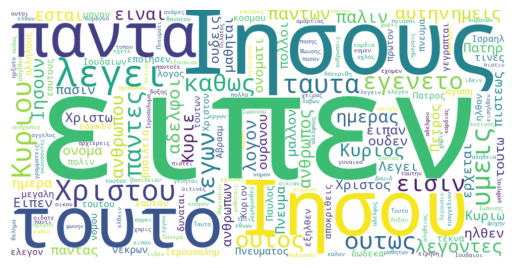

In [ ]:
print("abcdef"[:-1])
#!conda install -y WordCloud
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import unicodedata
def raccs_common(text):
    d = {
        #ord('\N{COMBINING ACUTE ACCENT}'):None,
        ord('’'): None,  # RIGHT SINGLE QUOTATION MARK
        ord('‘'): None,  # LEFT SINGLE QUOTATION MARK
        ord('“'): None,  # LEFT DOUBLE QUOTATION MARK
        ord('”'): None,  # RIGHT DOUBLE QUOTATION MARK
        ord('['): None,  # LEFT SINGLE QUOTATION MARK
        ord(']'): None,  # RIGHT SINGLE QUOTATION MARK
        ord('-'): None,   # HYPHEN-MINUS
        ord('’'): None,   # HYPHEN-MINUS
        ord('⧼'): None,  # LEFT WHITE ANGLE BRACKET
        ord('⧽'): None,  # RIGHT WHITE ANGLE BRACKET
        ord('*'): None,   # ASTERISK
        ord('⇔'): None,  # LEFT RIGHT DOUBLE ARROW
        ord('〉'): None,  # GREATER-THAN SIGN
        ord('〈'): None,  # LESS-THAN SIGN
        ord('‿'): None,  # LOW LINE
        ord('«'): None,  # LEFT-POINTING DOUBLE ANGLE QUOTATION MARK
        ord('»'): None,  # RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
        ord('‹'): None,  # SINGLE LEFT-POINTING ANGLE QUOTATION MARK
        ord('›'): None,  # SINGLE RIGHT-POINTING ANGLE QUOTATION MARK
        ord('('): None,  # LEFT PARENTHESIS
        ord(')'): None,  # RIGHT PARENTHESIS
        ord('-') : None,  # HYPHEN-MINUS
        ord(';') : None,  # SEMICOLON
        }
    return unicodedata.normalize('NFD', text).translate(d)

def raccsGK(text):
    d = {
        ord('\N{COMBINING ACUTE ACCENT}'):None,
        0x0300: None,  # COMBINING GRAVE ACCENT
        0x0301: None,  # COMBINING ACUTE ACCENT
        0x0342: None,  # COMBINING GREEK PERISPOMENI
        0x0313: None,  # COMBINING COMMA ABOVE (PSILI)
        0x0314: None,  # COMBINING REVERSED COMMA ABOVE (DASIA)
        0x0308: None,  # COMBINING DIAERESIS
        0x0304: None,  # COMBINING MACRON
        0x0306: None,  # COMBINING BREVE
        0x0323: None,  # COMBINING DOT BELOW
        0x033E: None,  # COMBINING VERTICAL LINE ABOVE
        0x0345: None,  # COMBINING GREEK YPOGEGRAMMENI
        0x0360: None,  # COMBINING TILDE
        0x034F: None,  # COMBINING GRAPHEME JOINER
        0x035C: None,  # COMBINING DOUBLE BREVE
        0x035E: None,  # COMBINING DOUBLE MACRON
        0x037A: None,  # GREEK YPOGEGRAMMENI
        0x1FBD: None,  # GREEK KORONIS
        0x1FBF: None,  # GREEK PSILI
        0x1FBE: None,  # GREEK DASIA
        0x1FFF: None,   # GREEK OXIA
        ord('’'): None,  # RIGHT SINGLE QUOTATION MARK
        ord('‘'): None,  # LEFT SINGLE QUOTATION MARK
        ord('“'): None,  # LEFT DOUBLE QUOTATION MARK
        ord('”'): None,  # RIGHT DOUBLE QUOTATION MARK
        ord('['): None,  # LEFT SINGLE QUOTATION MARK
        ord(']'): None,  # RIGHT SINGLE QUOTATION MARK
        ord('-'): None,   # HYPHEN-MINUS
        ord('’'): None,   # HYPHEN-MINUS
        ord('⧼'): None,  # LEFT WHITE ANGLE BRACKET
        ord('⧽'): None,  # RIGHT WHITE ANGLE BRACKET
        ord('*'): None,   # ASTERISK
        ord('⇔'): None,  # LEFT RIGHT DOUBLE ARROW
        ord('〉'): None,  # GREATER-THAN SIGN
        ord('〈'): None,  # LESS-THAN SIGN
        ord('‿'): None,  # LOW LINE
        ord('«'): None,  # LEFT-POINTING DOUBLE ANGLE QUOTATION MARK
        ord('»'): None,  # RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
        ord('‹'): None,  # SINGLE LEFT-POINTING ANGLE QUOTATION MARK
        ord('›'): None,  # SINGLE RIGHT-POINTING ANGLE QUOTATION MARK
        ord('('): None,  # LEFT PARENTHESIS
        ord(')'): None,  # RIGHT PARENTHESIS
# nestrādā .... nooooooooooooooooooooooo
        ord('-') : None,  # HYPHEN-MINUS
        ord(';') : None,  # SEMICOLON
        }
    return unicodedata.normalize('NFD', raccs_common(text)).translate(d)
    
def raccsLV(text):
    d = {
        }
    return unicodedata.normalize('NFD', raccs_common(text)).translate(d)


#text = "your input text goes here or load from file"

# Generate word cloud
#wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

word_counts = Counter()
ban_words = [raccsGK('καὶ'), raccsGK('του'), raccsGK('ο'), raccsGK('της'), raccsGK('την'), raccsGK('εν'), raccsGK('των'),\
             raccsGK('το'), raccsGK('Και'), raccsGK('αυτου'), raccsGK('εκ'), \
                 raccsGK('αυτων'), raccsGK('αυτης'), raccsGK('ειδον'), raccsGK('ενωπιον'), raccsGK('εστιν')]

for current_book in idxl.keys():
    for chapter in range(1, idxl[current_book] + 1):
        chptr = html_sources[bcom_to_bhub[current_book] + '_' + str(chapter)]
        for v in range(len(chptr)):
            for w in range(len(chptr[v])):
                word = raccsGK(chptr[v][w]['form'])
                if word and len(word)>4 and word not in ban_words and not word.startswith("αυτο"):
                    word_counts[word] += 1

# Generate word cloud from frequencies
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate_from_frequencies(word_counts)

# Display
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [ ]:
print(word_counts)
print(word_counts[raccsGK('Ἰησοῦς')])

Counter({'αυτον': 963, 'αυτοις': 559, 'ειπεν': 518, 'Ιησους': 457, 'αυτους': 358, 'Ιησου': 330, 'τουτο': 277, 'παντα': 254, 'λεγει': 252, 'Χριστου': 248, 'Κυριου': 226, 'υμεις': 206, 'ταυτα': 197, 'ουτως': 178, 'λεγων': 178, 'καθως': 175, 'παντες': 173, 'εγενετο': 163, 'εισιν': 155, 'ουτος': 154, 'αυτος': 152, 'λεγοντες': 151, 'Κυριος': 141, 'αδελφοι': 138, 'αυτην': 137, 'παντων': 133, 'ανθρωπου': 131, 'λογον': 130, 'Ιησουν': 129, 'ειναι': 126, 'ημερας': 125, 'παλιν': 124, 'ανθρωπος': 115, 'εσται': 115, 'ημεις': 112, 'Κυριε': 112, 'Χριστος': 111, 'μαθηται': 109, 'ημερα': 108, 'ονομα': 105, 'Χριστω': 103, 'ανθρωπων': 100, 'Πετρος': 100, 'Πνευμα': 97, 'Ειπεν': 96, 'Κυριω': 95, 'ονοματι': 95, 'πιστεως': 94, 'ουρανου': 91, 'παντας': 90, 'Πατηρ': 89, 'τουτω': 89, 'ειπαν': 88, 'ουδεις': 86, 'Λεγει': 86, 'ερχεται': 85, 'ηλθεν': 84, 'αυτοι': 83, 'μαλλον': 81, 'πολλοι': 80, 'ουδεν': 80, 'πασιν': 79, 'Πνευματος': 78, 'Παυλος': 78, 'βασιλεια': 77, 'νεκρων': 77, 'τινες': 76, 'Ιερουσαλημ': 76, 'επο

In [33]:
import sqlite3
conn = sqlite3.connect('links.db')
cursor = conn.cursor()

cursor.execute("SELECT key, value FROM links")

# Fetch all rows
rows = cursor.fetchall()

allrows = {}
# Loop through results
for row in rows:
    allrows[row[0]]=row[1]
    arr= row[0].split("_")
    arrlv= row[1].split(":")
    #print(arr)
    #print((names[arr[0]]))
    #print(html_sources.keys())
    st = ""
    if len(arrlv) >1:
        for j in range(len(arrlv)):
           st+=  result[arr[0]+"_"+str(int(arr[1]))][int(arr[2])-1][int(arrlv[j])-1]["form"]+" "
        print(st)
    else:
        print(result[arr[0]+"_"+str(int(arr[1]))][int(arr[2])-1][int(arrlv[0])-1]["form"])
    print(html_sources[names[arr[0]]+"_"+str(int(arr[1]))][int(arr[2])-1][int(arr[3])-1]["form"])
    print(f"Key: {row[0]}, Value: {row[1]}")

# Clean up
conn.close()


Pēteris
Πέτρος
Key: 1PE_1_1_1, Value: 1
apustulis
ἀπόστολος
Key: 1PE_1_1_2, Value: 4
Jēzus
Ἰησοῦ
Key: 1PE_1_1_3, Value: 2
Kristus
Χριστοῦ
Key: 1PE_1_1_4, Value: 3
svešiniekiem
παρεπιδήμοις
Key: 1PE_1_1_6, Value: 5
kas izkaisīti 
Διασπορᾶς
Key: 1PE_1_1_7, Value: 6:7
Pontā
Πόντου
Key: 1PE_1_1_8, Value: 8
Galatijā
Γαλατίας
Key: 1PE_1_1_9, Value: 9
Kapadoķijā
Καππαδοκίας
Key: 1PE_1_1_10, Value: 10
Āzijā
Ἀσίας
Key: 1PE_1_1_11, Value: 11
un
καὶ
Key: 1PE_1_1_12, Value: 12
Bitinijā
Βιθυνίας
Key: 1PE_1_1_13, Value: 13
pēc
κατὰ
Key: 1PE_1_2_1, Value: 4
iepriekšējā lēmuma 
πρόγνωσιν
Key: 1PE_1_2_2, Value: 5:6
Dievs
Θεοῦ
Key: 1PE_1_2_3, Value: 2
Tēvs
Πατρός
Key: 1PE_1_2_4, Value: 3
svētīdams
ἐν
Key: 1PE_1_2_5, Value: 9
svētīdams
ἁγιασμῷ
Key: 1PE_1_2_6, Value: 9
Garā
Πνεύματος
Key: 1PE_1_2_7, Value: 8
būtu paklausīgi 
ὑπακοὴν
Key: 1PE_1_2_9, Value: 12:13
un
καὶ
Key: 1PE_1_2_10, Value: 14
taptu apslacināti 
ῥαντισμὸν
Key: 1PE_1_2_11, Value: 15:16
asinīm
αἵματος
Key: 1PE_1_2_12, Value: 20
Jēzus
Ἰησοῦ